# Vehicle Routing Problem with Time Windows (VRPTW)
## Projet d'Optimisation Discrète – Polytech Lyon

Ce notebook implémente deux métaheuristiques pour résoudre le VRPTW :
- **Recuit Simulé (Simulated Annealing)**
- **Algorithme Génétique (Genetic Algorithm)**

L'objectif est de minimiser la distance totale parcourue par l'ensemble des véhicules en respectant :
- La capacité maximale $C$ de chaque véhicule
- Les fenêtres de temps $[e_i, l_i]$ de chaque client
- Le temps de service $s_i$ à chaque client

## 1. Importation des bibliothèques

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as mpatches
import random
import time
import copy
import math
import os
import glob
from itertools import permutations
from collections import defaultdict

# Fixer la seed pour la reproductibilité
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Bibliothèques importées avec succès !")
print(f"NumPy  : {np.__version__}")
print(f"Pandas : {pd.__version__}")

Bibliothèques importées avec succès !
NumPy  : 2.4.4
Pandas : 3.0.2


## 2. Chargement et parsing des données

Format des fichiers `.vrp` :
- `NB_CLIENTS`, `MAX_QUANTITY` : paramètres globaux
- `DATA_DEPOTS` : `id x y readyTime dueTime`
- `DATA_CLIENTS` : `id x y readyTime dueTime demand service`

In [2]:
def parse_vrp_file(filepath):
    """
    Lit un fichier .vrp et retourne un dictionnaire contenant :
      - 'name'        : nom du problème
      - 'capacity'    : capacité max des véhicules
      - 'depot'       : dict {x, y, ready, due}
      - 'clients'     : liste de dicts {id, x, y, ready, due, demand, service}
    """
    data = {}
    clients = []
    depot = None
    mode = None

    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('#'):
                continue

            if line.startswith('NAME:'):
                data['name'] = line.split(':', 1)[1].strip()
            elif line.startswith('NB_CLIENTS:'):
                data['nb_clients'] = int(line.split(':', 1)[1].strip())
            elif line.startswith('MAX_QUANTITY:'):
                data['capacity'] = int(line.split(':', 1)[1].strip())
            elif line.startswith('DATA_DEPOTS'):
                mode = 'depot'
            elif line.startswith('DATA_CLIENTS'):
                mode = 'clients'
            elif mode == 'depot' and not line.startswith('DATA_'):
                parts = line.split()
                if len(parts) >= 5:
                    depot = {
                        'id': 0,
                        'name': parts[0],
                        'x': float(parts[1]),
                        'y': float(parts[2]),
                        'ready': float(parts[3]),
                        'due': float(parts[4]),
                        'demand': 0,
                        'service': 0
                    }
            elif mode == 'clients' and not line.startswith('DATA_'):
                parts = line.split()
                if len(parts) >= 7:
                    idx = len(clients) + 1
                    clients.append({
                        'id': idx,
                        'name': parts[0],
                        'x': float(parts[1]),
                        'y': float(parts[2]),
                        'ready': float(parts[3]),
                        'due': float(parts[4]),
                        'demand': float(parts[5]),
                        'service': float(parts[6])
                    })

    data['depot'] = depot
    data['clients'] = clients
    return data


# Charger tous les fichiers de données
DATA_DIR = r"c:\Users\alext\OneDrive\Bureau\tp opti"
vrp_files = sorted(glob.glob(os.path.join(DATA_DIR, "data*.vrp")))

datasets = {}
for f in vrp_files:
    name = os.path.splitext(os.path.basename(f))[0]
    datasets[name] = parse_vrp_file(f)
    d = datasets[name]
    print(f"{name:12s} | {d['nb_clients']:4d} clients | capacité={d['capacity']:5d} | "
          f"dépôt=({d['depot']['x']:.0f},{d['depot']['y']:.0f})")

data101      |  100 clients | capacité=  200 | dépôt=(35,35)
data102      |  100 clients | capacité=  200 | dépôt=(35,35)
data1101     |  100 clients | capacité=  200 | dépôt=(40,50)
data1102     |  100 clients | capacité=  200 | dépôt=(40,50)
data111      |  100 clients | capacité=  200 | dépôt=(35,35)
data112      |  100 clients | capacité=  200 | dépôt=(35,35)
data1201     |  100 clients | capacité= 1000 | dépôt=(40,50)
data1202     |  100 clients | capacité= 1000 | dépôt=(40,50)
data201      |  100 clients | capacité= 1000 | dépôt=(35,35)
data202      |  100 clients | capacité= 1000 | dépôt=(35,35)


## 3. Modélisation du problème (structures de données)

Chaque instance VRPTW est représentée par :
- Un **dépôt** (nœud 0)
- Des **clients** $1 \ldots n$ avec demande $q_i$, fenêtre $[e_i, l_i]$, service $s_i$
- Des **routes** : séquences de clients entre deux passages au dépôt
- Une **solution** : ensemble de routes couvrant tous les clients

In [3]:
class VRPTWInstance:
    """Représente une instance du problème VRPTW."""
    
    def __init__(self, data: dict):
        self.name = data['name']
        self.capacity = data['capacity']
        self.depot = data['depot']
        self.clients = data['clients']
        self.n = len(self.clients)
        
        # Construire les nœuds : 0=dépôt, 1..n = clients
        self.nodes = [self.depot] + self.clients
        
        # Matrice de distances
        self.dist = self._compute_distance_matrix()
    
    def _compute_distance_matrix(self):
        """Calcule la matrice de distances euclidiennes."""
        n = len(self.nodes)
        dist = np.zeros((n, n))
        for i in range(n):
            for j in range(n):
                dx = self.nodes[i]['x'] - self.nodes[j]['x']
                dy = self.nodes[i]['y'] - self.nodes[j]['y']
                dist[i][j] = math.sqrt(dx*dx + dy*dy)
        return dist
    
    def client_ids(self):
        """Retourne la liste des IDs de clients (1..n)."""
        return list(range(1, self.n + 1))


class Route:
    """Une route = liste ordonnée de clients (sans le dépôt en début/fin)."""
    
    def __init__(self, client_ids=None):
        self.clients = client_ids if client_ids is not None else []
    
    def copy(self):
        return Route(list(self.clients))
    
    def __repr__(self):
        return f"Route({self.clients})"
    
    def __len__(self):
        return len(self.clients)


class Solution:
    """Ensemble de routes représentant une solution complète."""
    
    def __init__(self, routes=None):
        self.routes = routes if routes is not None else []
    
    def copy(self):
        return Solution([r.copy() for r in self.routes])
    
    def num_routes(self):
        return len(self.routes)
    
    def all_clients(self):
        """Retourne tous les clients visités dans l'ordre des routes."""
        result = []
        for r in self.routes:
            result.extend(r.clients)
        return result
    
    def __repr__(self):
        return f"Solution({len(self.routes)} routes, clients={self.all_clients()})"


# Test de la structure
inst = VRPTWInstance(datasets['data101'])
print(f"Instance : {inst.name}")
print(f"Nombre de clients : {inst.n}")
print(f"Capacité véhicule : {inst.capacity}")
print(f"Dépôt : ({inst.depot['x']}, {inst.depot['y']}), fenêtre=[{inst.depot['ready']}, {inst.depot['due']}]")
print(f"Client 1 : {inst.clients[0]}")
print(f"Taille matrice dist : {inst.dist.shape}")
print(f"Distance dépôt → client 1 : {inst.dist[0][1]:.2f}")

Instance : data101.vrp
Nombre de clients : 100
Capacité véhicule : 200
Dépôt : (35.0, 35.0), fenêtre=[0.0, 230.0]
Client 1 : {'id': 1, 'name': 'c1', 'x': 41.0, 'y': 49.0, 'ready': 161.0, 'due': 171.0, 'demand': 10.0, 'service': 10.0}
Taille matrice dist : (101, 101)
Distance dépôt → client 1 : 15.23


## 4. Calcul des distances et visualisation de la matrice

$$d_{ij} = \sqrt{(x_i - x_j)^2 + (y_i - y_j)^2}$$

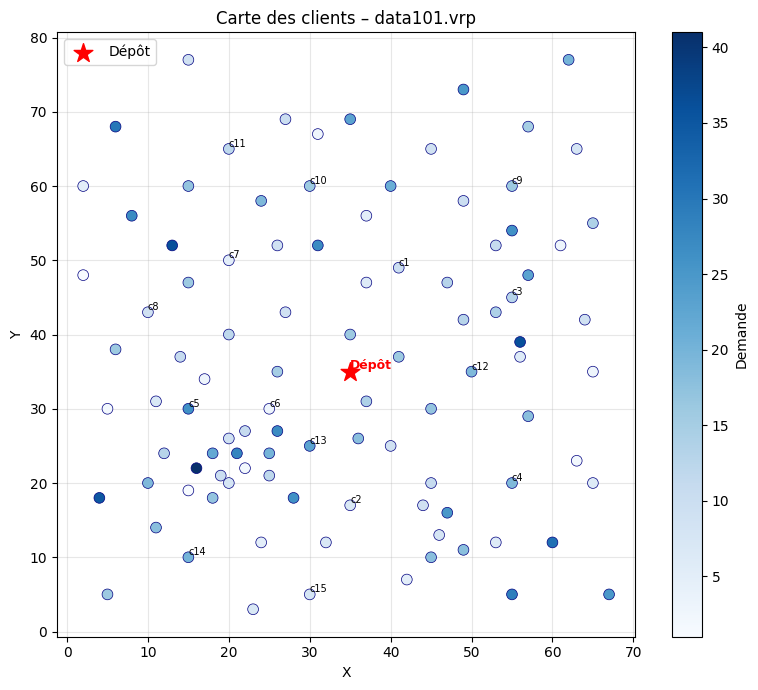

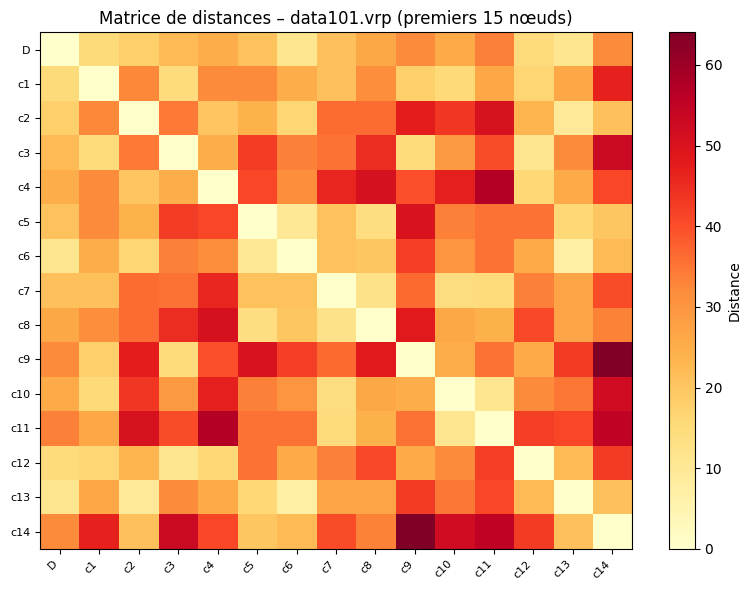

In [4]:
def plot_distance_matrix(inst, max_nodes=20):
    """Visualise la sous-matrice de distances des premiers nœuds."""
    n = min(max_nodes, len(inst.nodes))
    sub = inst.dist[:n, :n]
    labels = ['D'] + [f'c{i}' for i in range(1, n)]
    
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(sub, cmap='YlOrRd', aspect='auto')
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(labels, fontsize=8)
    plt.colorbar(im, ax=ax, label='Distance')
    ax.set_title(f'Matrice de distances – {inst.name} (premiers {n} nœuds)')
    plt.tight_layout()
    plt.show()


def plot_client_map(inst, title=None):
    """Affiche la carte des clients et du dépôt."""
    fig, ax = plt.subplots(figsize=(8, 7))
    
    xs = [c['x'] for c in inst.clients]
    ys = [c['y'] for c in inst.clients]
    demands = [c['demand'] for c in inst.clients]
    
    sc = ax.scatter(xs, ys, c=demands, cmap='Blues', s=60, zorder=3, edgecolors='navy', linewidths=0.5)
    plt.colorbar(sc, ax=ax, label='Demande')
    
    # Annoter quelques clients
    for i, c in enumerate(inst.clients[:15]):
        ax.annotate(f"c{c['id']}", (c['x'], c['y']), fontsize=7, ha='left', va='bottom')
    
    # Dépôt
    ax.scatter([inst.depot['x']], [inst.depot['y']], c='red', s=200, marker='*', zorder=5, label='Dépôt')
    ax.annotate('Dépôt', (inst.depot['x'], inst.depot['y']), fontsize=9, ha='left', va='bottom', color='red', fontweight='bold')
    
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title(title or f'Carte des clients – {inst.name}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# Afficher pour data101
inst101 = VRPTWInstance(datasets['data101'])
plot_client_map(inst101)
plot_distance_matrix(inst101, max_nodes=15)

## 5. Détermination du nombre minimum de véhicules

La borne inférieure est :
$$V_{min} = \left\lceil \frac{\sum_{i=1}^{n} q_i}{C} \right\rceil$$

Jeu de données  Nb clients  Capacité C  Demande totale  Véhicules min (borne inf.)
       data101         100         200          1458.0                           8
       data102         100         200          1458.0                           8
      data1101         100         200          1724.0                           9
      data1102         100         200          1724.0                           9
       data111         100         200          1458.0                           8
       data112         100         200          1458.0                           8
      data1201         100        1000          1724.0                           2
      data1202         100        1000          1724.0                           2
       data201         100        1000          1458.0                           2
       data202         100        1000          1458.0                           2


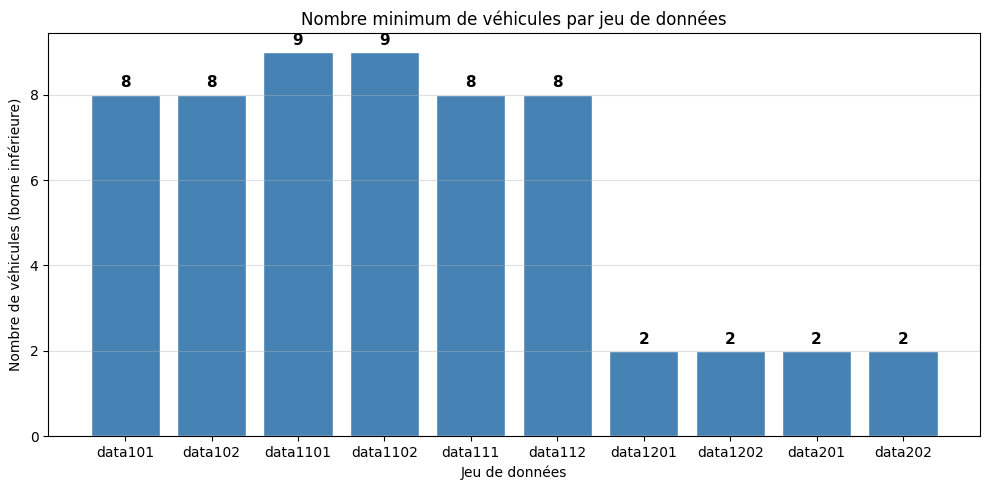

In [5]:
def min_vehicles_lower_bound(inst):
    """Calcule la borne inférieure du nombre de véhicules nécessaires."""
    total_demand = sum(c['demand'] for c in inst.clients)
    return math.ceil(total_demand / inst.capacity)


# Calculer et afficher pour tous les jeux de données
rows = []
for name, data in datasets.items():
    inst_tmp = VRPTWInstance(data)
    vmin = min_vehicles_lower_bound(inst_tmp)
    total_q = sum(c['demand'] for c in inst_tmp.clients)
    rows.append({
        'Jeu de données': name,
        'Nb clients': inst_tmp.n,
        'Capacité C': inst_tmp.capacity,
        'Demande totale': total_q,
        'Véhicules min (borne inf.)': vmin
    })

df_vehicles = pd.DataFrame(rows)
print(df_vehicles.to_string(index=False))

# Graphique en barres
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['steelblue' if v <= 10 else 'salmon' for v in df_vehicles['Véhicules min (borne inf.)'].values]
bars = ax.bar(df_vehicles['Jeu de données'], df_vehicles['Véhicules min (borne inf.)'], color=colors, edgecolor='white')
for bar, val in zip(bars, df_vehicles['Véhicules min (borne inf.)'].values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_xlabel('Jeu de données')
ax.set_ylabel('Nombre de véhicules (borne inférieure)')
ax.set_title('Nombre minimum de véhicules par jeu de données')
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

## 6. Validation des contraintes

Deux types de contraintes :
1. **Capacité** : $\sum_{i \in \text{route}} q_i \leq C$
2. **Fenêtres de temps** : $e_i \leq t_i \leq l_i$ (avec attente si arrivée avant $e_i$)

In [6]:
def route_capacity_ok(route: Route, inst: VRPTWInstance) -> bool:
    """Vérifie que la capacité de la route n'est pas dépassée."""
    total = sum(inst.nodes[c]['demand'] for c in route.clients)
    return total <= inst.capacity


def route_time_ok(route: Route, inst: VRPTWInstance) -> (bool, float):
    """
    Vérifie les fenêtres de temps d'une route.
    Retourne (valide, temps_retour_depot).
    Le véhicule peut attendre si e_i n'est pas encore atteint.
    """
    t = inst.depot['ready']
    prev = 0  # index dépôt
    for cid in route.clients:
        t += inst.dist[prev][cid]
        node = inst.nodes[cid]
        if t > node['due']:
            return False, t  # Arrivée trop tard
        t = max(t, node['ready'])  # Attendre si arrivée trop tôt
        t += node['service']
        prev = cid
    # Retour au dépôt
    t += inst.dist[prev][0]
    if t > inst.depot['due']:
        return False, t
    return True, t


def route_time_violation(route: Route, inst: VRPTWInstance) -> float:
    """
    Calcule la violation de fenêtre de temps (somme des retards).
    Retourne 0 si tout est valide.
    """
    t = inst.depot['ready']
    prev = 0
    violation = 0.0
    for cid in route.clients:
        t += inst.dist[prev][cid]
        node = inst.nodes[cid]
        if t > node['due']:
            violation += t - node['due']
        t = max(t, node['ready'])
        t += node['service']
        prev = cid
    t += inst.dist[prev][0]
    if t > inst.depot['due']:
        violation += t - inst.depot['due']
    return violation


def solution_is_valid(sol: Solution, inst: VRPTWInstance, check_tw: bool = True) -> bool:
    """Vérifie qu'une solution est complète et valide."""
    visited = []
    for r in sol.routes:
        if not route_capacity_ok(r, inst):
            return False
        if check_tw:
            ok, _ = route_time_ok(r, inst)
            if not ok:
                return False
        visited.extend(r.clients)
    # Tous les clients visités une seule fois
    return sorted(visited) == list(range(1, inst.n + 1))


def solution_total_violation(sol: Solution, inst: VRPTWInstance) -> float:
    """Retourne la violation totale des fenêtres de temps d'une solution."""
    return sum(route_time_violation(r, inst) for r in sol.routes)


print("Fonctions de validation définies.")

Fonctions de validation définies.


## 7. Fonction objectif

$$D_{total} = \sum_{k=1}^{K} \left( d_{0, \pi_k(1)} + \sum_{j=1}^{|\pi_k|-1} d_{\pi_k(j), \pi_k(j+1)} + d_{\pi_k(|\pi_k|), 0} \right)$$

où $\pi_k$ est la séquence de clients de la route $k$.

In [7]:
def route_distance(route: Route, inst: VRPTWInstance) -> float:
    """Distance totale d'une route (dépôt → clients → dépôt)."""
    if not route.clients:
        return 0.0
    d = inst.dist[0][route.clients[0]]
    for i in range(len(route.clients) - 1):
        d += inst.dist[route.clients[i]][route.clients[i+1]]
    d += inst.dist[route.clients[-1]][0]
    return d


def total_distance(sol: Solution, inst: VRPTWInstance) -> float:
    """Distance totale de toute la solution."""
    return sum(route_distance(r, inst) for r in sol.routes)


def penalized_cost(sol: Solution, inst: VRPTWInstance, penalty: float = 1000.0) -> float:
    """
    Coût pénalisé = distance + penalty * violation_TW.
    Utilisé pour guider les métaheuristiques même en cas de violation.
    """
    dist = total_distance(sol, inst)
    viol = solution_total_violation(sol, inst)
    return dist + penalty * viol


print("Fonctions objectif définies.")

Fonctions objectif définies.


## 8. Générateur aléatoire de solutions

Construction par insertion aléatoire :
1. Mélanger aléatoirement les clients
2. Pour chaque client, essayer de l'insérer dans une route existante (contrainte capacité)
3. Si impossible, ouvrir une nouvelle route

In [8]:
def random_solution(inst: VRPTWInstance, check_tw: bool = False, rng=None) -> Solution:
    """
    Génère une solution initiale aléatoire.
    - check_tw=False : ne vérifie que la capacité (phase 1)
    - check_tw=True  : vérifie aussi les fenêtres de temps (phase 2)
    """
    if rng is None:
        rng = random.Random()
    
    client_ids = list(range(1, inst.n + 1))
    rng.shuffle(client_ids)
    
    routes = []
    
    for cid in client_ids:
        demand = inst.nodes[cid]['demand']
        inserted = False
        
        # Essayer dans une route existante (ordre aléatoire)
        route_order = list(range(len(routes)))
        rng.shuffle(route_order)
        
        for ri in route_order:
            r = routes[ri]
            # Vérifier la capacité
            current_load = sum(inst.nodes[c]['demand'] for c in r.clients)
            if current_load + demand > inst.capacity:
                continue
            
            if check_tw:
                # Trouver la meilleure position dans la route
                best_pos = None
                best_cost = float('inf')
                for pos in range(len(r.clients) + 1):
                    new_clients = r.clients[:pos] + [cid] + r.clients[pos:]
                    tmp_route = Route(new_clients)
                    ok, _ = route_time_ok(tmp_route, inst)
                    if ok:
                        cost = route_distance(tmp_route, inst)
                        if cost < best_cost:
                            best_cost = cost
                            best_pos = pos
                if best_pos is not None:
                    r.clients.insert(best_pos, cid)
                    inserted = True
                    break
            else:
                r.clients.append(cid)
                inserted = True
                break
        
        if not inserted:
            routes.append(Route([cid]))
    
    # Supprimer les routes vides
    routes = [r for r in routes if r.clients]
    return Solution(routes)


def greedy_solution(inst: VRPTWInstance) -> Solution:
    """
    Construit une solution par heuristique greedy (nearest neighbor).
    """
    unvisited = set(range(1, inst.n + 1))
    routes = []
    
    while unvisited:
        route_clients = []
        current_load = 0
        current_pos = 0  # dépôt
        current_time = inst.depot['ready']
        
        while True:
            best = None
            best_dist = float('inf')
            
            for cid in unvisited:
                d = inst.demand if hasattr(inst, 'demand') else inst.nodes[cid]['demand']
                demand = inst.nodes[cid]['demand']
                if current_load + demand > inst.capacity:
                    continue
                
                travel = inst.dist[current_pos][cid]
                arr = current_time + travel
                node = inst.nodes[cid]
                
                if arr > node['due']:
                    continue
                
                if travel < best_dist:
                    best_dist = travel
                    best = cid
            
            if best is None:
                break
            
            unvisited.remove(best)
            route_clients.append(best)
            current_load += inst.nodes[best]['demand']
            travel = inst.dist[current_pos][best]
            current_time += travel
            current_time = max(current_time, inst.nodes[best]['ready'])
            current_time += inst.nodes[best]['service']
            current_pos = best
        
        if route_clients:
            routes.append(Route(route_clients))
        elif unvisited:
            # Forcer l'ajout du client avec violation pour ne pas boucler
            cid = next(iter(unvisited))
            unvisited.remove(cid)
            routes.append(Route([cid]))
    
    return Solution(routes)


# Test sur data101
rng_test = random.Random(42)
sol_rand = random_solution(inst101, check_tw=False, rng=rng_test)
sol_greedy = greedy_solution(inst101)

print(f"=== Solution aléatoire (sans TW) ===")
print(f"  Nombre de routes  : {sol_rand.num_routes()}")
print(f"  Distance totale   : {total_distance(sol_rand, inst101):.2f}")
print(f"  Violation TW      : {solution_total_violation(sol_rand, inst101):.2f}")
print(f"  Valide (cap)      : {solution_is_valid(sol_rand, inst101, check_tw=False)}")

print(f"\n=== Solution greedy ===")
print(f"  Nombre de routes  : {sol_greedy.num_routes()}")
print(f"  Distance totale   : {total_distance(sol_greedy, inst101):.2f}")
print(f"  Violation TW      : {solution_total_violation(sol_greedy, inst101):.2f}")
print(f"  Valide (avec TW)  : {solution_is_valid(sol_greedy, inst101, check_tw=True)}")

=== Solution aléatoire (sans TW) ===
  Nombre de routes  : 8
  Distance totale   : 3560.75
  Violation TW      : 33658.40
  Valide (cap)      : True

=== Solution greedy ===
  Nombre de routes  : 37
  Distance totale   : 2623.24
  Violation TW      : 0.00
  Valide (avec TW)  : True


## 9. Opérateurs de voisinage

Trois opérateurs :
- **2-opt intra-route** : inverse un segment d'une route
- **Relocate** : déplace un client d'une route vers une autre
- **Swap** : échange deux clients entre deux routes différentes

In [9]:
def two_opt_intra(sol: Solution, inst: VRPTWInstance, check_tw: bool = True) -> Solution:
    """
    2-opt intra-route : inverse un segment [i..j] dans une route.
    Retourne la meilleure solution voisine trouvée.
    """
    best_sol = sol
    best_cost = penalized_cost(sol, inst) if check_tw else total_distance(sol, inst)
    
    for ri, route in enumerate(sol.routes):
        n = len(route.clients)
        if n < 4:
            continue
        for i in range(1, n - 1):
            for j in range(i + 1, n):
                new_clients = route.clients[:i] + list(reversed(route.clients[i:j+1])) + route.clients[j+1:]
                new_route = Route(new_clients)
                
                if not route_capacity_ok(new_route, inst):
                    continue
                
                new_sol = sol.copy()
                new_sol.routes[ri] = new_route
                
                cost = penalized_cost(new_sol, inst) if check_tw else total_distance(new_sol, inst)
                if cost < best_cost:
                    best_cost = cost
                    best_sol = new_sol
    
    return best_sol


def relocate(sol: Solution, inst: VRPTWInstance, check_tw: bool = True) -> Solution:
    """
    Relocate : déplace un client d'une route vers la meilleure position d'une autre route.
    """
    best_sol = sol
    best_cost = penalized_cost(sol, inst) if check_tw else total_distance(sol, inst)
    
    for ri in range(len(sol.routes)):
        for ci, cid in enumerate(sol.routes[ri].clients):
            demand = inst.nodes[cid]['demand']
            
            for rj in range(len(sol.routes)):
                if ri == rj:
                    continue
                
                # Vérifier la capacité de la route destination
                load_rj = sum(inst.nodes[c]['demand'] for c in sol.routes[rj].clients)
                if load_rj + demand > inst.capacity:
                    continue
                
                for pos in range(len(sol.routes[rj].clients) + 1):
                    new_sol = sol.copy()
                    new_sol.routes[ri].clients.pop(ci)
                    new_sol.routes[rj].clients.insert(pos, cid)
                    
                    # Supprimer routes vides
                    new_sol.routes = [r for r in new_sol.routes if r.clients]
                    
                    cost = penalized_cost(new_sol, inst) if check_tw else total_distance(new_sol, inst)
                    if cost < best_cost:
                        best_cost = cost
                        best_sol = new_sol
    
    return best_sol


def swap(sol: Solution, inst: VRPTWInstance, check_tw: bool = True) -> Solution:
    """
    Swap : échange deux clients entre deux routes différentes.
    """
    best_sol = sol
    best_cost = penalized_cost(sol, inst) if check_tw else total_distance(sol, inst)
    
    for ri in range(len(sol.routes)):
        for ci, cid_i in enumerate(sol.routes[ri].clients):
            for rj in range(ri + 1, len(sol.routes)):
                for cj, cid_j in enumerate(sol.routes[rj].clients):
                    # Vérifier capacités après échange
                    load_ri = sum(inst.nodes[c]['demand'] for c in sol.routes[ri].clients)
                    load_rj = sum(inst.nodes[c]['demand'] for c in sol.routes[rj].clients)
                    
                    new_load_ri = load_ri - inst.nodes[cid_i]['demand'] + inst.nodes[cid_j]['demand']
                    new_load_rj = load_rj - inst.nodes[cid_j]['demand'] + inst.nodes[cid_i]['demand']
                    
                    if new_load_ri > inst.capacity or new_load_rj > inst.capacity:
                        continue
                    
                    new_sol = sol.copy()
                    new_sol.routes[ri].clients[ci] = cid_j
                    new_sol.routes[rj].clients[cj] = cid_i
                    
                    cost = penalized_cost(new_sol, inst) if check_tw else total_distance(new_sol, inst)
                    if cost < best_cost:
                        best_cost = cost
                        best_sol = new_sol
    
    return best_sol


def random_neighbor(sol: Solution, inst: VRPTWInstance, rng, check_tw: bool = True) -> Solution:
    """
    Génère un voisin aléatoire en appliquant un opérateur aléatoire.
    """
    op = rng.choice(['2opt', 'relocate', 'swap'])
    new_sol = sol.copy()
    
    if op == '2opt':
        routes_with_4 = [i for i, r in enumerate(new_sol.routes) if len(r) >= 4]
        if not routes_with_4:
            op = 'relocate'
        else:
            ri = rng.choice(routes_with_4)
            n = len(new_sol.routes[ri].clients)
            i = rng.randint(1, n - 2)
            j = rng.randint(i + 1, n - 1)
            new_sol.routes[ri].clients[i:j+1] = reversed(new_sol.routes[ri].clients[i:j+1])
    
    if op == 'relocate':
        if len(new_sol.routes) >= 2:
            ri = rng.randint(0, len(new_sol.routes) - 1)
            if new_sol.routes[ri].clients:
                ci = rng.randint(0, len(new_sol.routes[ri].clients) - 1)
                cid = new_sol.routes[ri].clients[ci]
                demand = inst.nodes[cid]['demand']
                
                rj_candidates = [
                    j for j in range(len(new_sol.routes)) 
                    if j != ri and sum(inst.nodes[c]['demand'] for c in new_sol.routes[j].clients) + demand <= inst.capacity
                ]
                if rj_candidates:
                    rj = rng.choice(rj_candidates)
                    pos = rng.randint(0, len(new_sol.routes[rj].clients))
                    new_sol.routes[ri].clients.pop(ci)
                    new_sol.routes[rj].clients.insert(pos, cid)
                    new_sol.routes = [r for r in new_sol.routes if r.clients]
    
    elif op == 'swap':
        if len(new_sol.routes) >= 2:
            ri, rj = rng.sample(range(len(new_sol.routes)), 2)
            if new_sol.routes[ri].clients and new_sol.routes[rj].clients:
                ci = rng.randint(0, len(new_sol.routes[ri].clients) - 1)
                cj = rng.randint(0, len(new_sol.routes[rj].clients) - 1)
                cid_i = new_sol.routes[ri].clients[ci]
                cid_j = new_sol.routes[rj].clients[cj]
                
                load_ri = sum(inst.nodes[c]['demand'] for c in new_sol.routes[ri].clients)
                load_rj = sum(inst.nodes[c]['demand'] for c in new_sol.routes[rj].clients)
                new_load_ri = load_ri - inst.nodes[cid_i]['demand'] + inst.nodes[cid_j]['demand']
                new_load_rj = load_rj - inst.nodes[cid_j]['demand'] + inst.nodes[cid_i]['demand']
                
                if new_load_ri <= inst.capacity and new_load_rj <= inst.capacity:
                    new_sol.routes[ri].clients[ci] = cid_j
                    new_sol.routes[rj].clients[cj] = cid_i
    
    return new_sol


print("Opérateurs de voisinage définis.")

Opérateurs de voisinage définis.


## 10. Métaheuristique 1 : Recuit Simulé (Simulated Annealing)

Algorithme :
1. Partir d'une solution initiale $s_0$
2. À chaque itération, générer un voisin $s'$
3. Accepter $s'$ si $\Delta f \leq 0$ ou avec probabilité $P = e^{-\Delta f / T}$
4. Refroidissement : $T \leftarrow \alpha \cdot T$

$$P(\text{accepter}) = e^{-\Delta f / T}$$

In [10]:
def simulated_annealing(
    inst: VRPTWInstance,
    check_tw: bool = True,
    T0: float = 500.0,
    alpha: float = 0.995,
    max_iter: int = 10000,
    seed: int = 42
) -> dict:
    """
    Recuit Simulé pour le VRPTW.
    
    Paramètres :
      - T0       : température initiale
      - alpha    : facteur de refroidissement (0 < alpha < 1)
      - max_iter : nombre max d'itérations
      - check_tw : prendre en compte les fenêtres de temps
    
    Retourne un dict avec la meilleure solution, historique de convergence, etc.
    """
    rng = random.Random(seed)
    
    # Solution initiale (greedy)
    current = greedy_solution(inst)
    current_cost = penalized_cost(current, inst) if check_tw else total_distance(current, inst)
    
    best = current.copy()
    best_cost = current_cost
    
    T = T0
    history = []
    history_best = []
    nb_accepted = 0
    nb_generated = 0
    
    start = time.time()
    
    for it in range(max_iter):
        neighbor = random_neighbor(current, inst, rng, check_tw=check_tw)
        neighbor_cost = penalized_cost(neighbor, inst) if check_tw else total_distance(neighbor, inst)
        nb_generated += 1
        
        delta = neighbor_cost - current_cost
        
        if delta <= 0 or rng.random() < math.exp(-delta / max(T, 1e-10)):
            current = neighbor
            current_cost = neighbor_cost
            nb_accepted += 1
            
            if current_cost < best_cost:
                best = current.copy()
                best_cost = current_cost
        
        T *= alpha
        
        if it % 100 == 0:
            history.append(current_cost)
            history_best.append(best_cost)
    
    elapsed = time.time() - start
    
    return {
        'algorithm': 'Recuit Simulé',
        'solution': best,
        'best_cost': best_cost,
        'distance': total_distance(best, inst),
        'violation': solution_total_violation(best, inst),
        'num_routes': best.num_routes(),
        'nb_generated': nb_generated,
        'nb_accepted': nb_accepted,
        'time': elapsed,
        'history': history,
        'history_best': history_best,
        'params': {'T0': T0, 'alpha': alpha, 'max_iter': max_iter, 'check_tw': check_tw}
    }


# Test rapide sur data101
print("Test Recuit Simulé sur data101...")
result_sa = simulated_annealing(inst101, check_tw=True, T0=500, alpha=0.995, max_iter=5000, seed=42)
print(f"  Distance    : {result_sa['distance']:.2f}")
print(f"  Violation TW: {result_sa['violation']:.4f}")
print(f"  Routes      : {result_sa['num_routes']}")
print(f"  Temps       : {result_sa['time']:.2f}s")
print(f"  Solutions générées : {result_sa['nb_generated']}")
print(f"  Solutions acceptées: {result_sa['nb_accepted']}")
print(f"  Valide : {solution_is_valid(result_sa['solution'], inst101, check_tw=True)}")

Test Recuit Simulé sur data101...
  Distance    : 2351.71
  Violation TW: 0.0000
  Routes      : 30
  Temps       : 0.71s
  Solutions générées : 5000
  Solutions acceptées: 123
  Valide : True


## 11. Métaheuristique 2 : Algorithme Génétique

Algorithme :
1. **Population** initiale de $P$ solutions
2. **Sélection** par tournoi (taille $k$)
3. **Croisement** OX (Order Crossover) entre deux parents
4. **Mutation** : relocate aléatoire avec probabilité $p_m$
5. Répéter pendant $G$ générations

In [11]:
def sol_to_chromosome(sol: Solution) -> list:
    """Convertit une solution en chromosome (séquence linéaire de clients avec séparateurs -1)."""
    chrom = []
    for i, r in enumerate(sol.routes):
        chrom.extend(r.clients)
        if i < len(sol.routes) - 1:
            chrom.append(-1)  # Séparateur de routes
    return chrom


def chromosome_to_sol(chrom: list, inst: VRPTWInstance) -> Solution:
    """
    Convertit un chromosome en solution.
    Coupe les routes dès que la capacité est dépassée (réparation).
    """
    routes = []
    current_clients = []
    current_load = 0
    
    for gene in chrom:
        if gene == -1:
            if current_clients:
                routes.append(Route(current_clients))
                current_clients = []
                current_load = 0
        else:
            demand = inst.nodes[gene]['demand']
            if current_load + demand > inst.capacity and current_clients:
                routes.append(Route(current_clients))
                current_clients = [gene]
                current_load = demand
            else:
                current_clients.append(gene)
                current_load += demand
    
    if current_clients:
        routes.append(Route(current_clients))
    
    return Solution([r for r in routes if r.clients])


def ox_crossover(parent1: Solution, parent2: Solution, inst: VRPTWInstance, rng) -> Solution:
    """
    OX Crossover (Order Crossover) adapté au VRP.
    Travaille sur la séquence de clients (sans les séparateurs).
    """
    clients_p1 = parent1.all_clients()
    clients_p2 = parent2.all_clients()
    n = len(clients_p1)
    
    if n < 2:
        return parent1.copy()
    
    # Sélectionner un segment de p1
    i, j = sorted(rng.sample(range(n), 2))
    
    child_clients = [None] * n
    child_clients[i:j+1] = clients_p1[i:j+1]
    segment_set = set(clients_p1[i:j+1])
    
    # Remplir avec p2 dans l'ordre
    remaining = [c for c in clients_p2 if c not in segment_set]
    pos = 0
    for k in range(n):
        if child_clients[k] is None:
            child_clients[k] = remaining[pos]
            pos += 1
    
    # Reconstruire les routes avec contrainte de capacité
    routes = []
    current_clients = []
    current_load = 0
    
    for cid in child_clients:
        demand = inst.nodes[cid]['demand']
        if current_load + demand > inst.capacity:
            if current_clients:
                routes.append(Route(current_clients))
            current_clients = [cid]
            current_load = demand
        else:
            current_clients.append(cid)
            current_load += demand
    
    if current_clients:
        routes.append(Route(current_clients))
    
    return Solution(routes)


def mutate(sol: Solution, inst: VRPTWInstance, rng, mutation_rate: float = 0.1) -> Solution:
    """Mutation : relocate aléatoire d'un client."""
    if rng.random() > mutation_rate:
        return sol
    return random_neighbor(sol, inst, rng, check_tw=False)


def tournament_select(population: list, fitnesses: list, k: int, rng) -> Solution:
    """Sélection par tournoi de taille k."""
    candidates = rng.sample(range(len(population)), min(k, len(population)))
    best_idx = min(candidates, key=lambda i: fitnesses[i])
    return population[best_idx].copy()


def genetic_algorithm(
    inst: VRPTWInstance,
    check_tw: bool = True,
    pop_size: int = 30,
    generations: int = 200,
    tournament_k: int = 5,
    mutation_rate: float = 0.2,
    elite_size: int = 2,
    seed: int = 42
) -> dict:
    """
    Algorithme Génétique pour le VRPTW.
    
    Paramètres :
      - pop_size    : taille de la population
      - generations : nombre de générations
      - tournament_k: taille du tournoi de sélection
      - mutation_rate: probabilité de mutation
      - elite_size  : nombre d'élites conservées par génération
      - check_tw    : prendre en compte les fenêtres de temps
    """
    rng = random.Random(seed)
    
    def fitness(sol):
        return penalized_cost(sol, inst) if check_tw else total_distance(sol, inst)
    
    # Générer la population initiale
    population = []
    population.append(greedy_solution(inst))
    for _ in range(pop_size - 1):
        population.append(random_solution(inst, check_tw=False, rng=rng))
    
    fitnesses = [fitness(s) for s in population]
    best_idx = min(range(pop_size), key=lambda i: fitnesses[i])
    best_sol = population[best_idx].copy()
    best_fit = fitnesses[best_idx]
    
    history = []
    history_best = []
    nb_generated = pop_size
    
    start = time.time()
    
    for gen in range(generations):
        # Tri pour élitisme
        sorted_idx = sorted(range(len(population)), key=lambda i: fitnesses[i])
        new_pop = [population[i].copy() for i in sorted_idx[:elite_size]]
        new_fits = [fitnesses[i] for i in sorted_idx[:elite_size]]
        
        while len(new_pop) < pop_size:
            p1 = tournament_select(population, fitnesses, tournament_k, rng)
            p2 = tournament_select(population, fitnesses, tournament_k, rng)
            child = ox_crossover(p1, p2, inst, rng)
            child = mutate(child, inst, rng, mutation_rate)
            f = fitness(child)
            new_pop.append(child)
            new_fits.append(f)
            nb_generated += 1
        
        population = new_pop
        fitnesses = new_fits
        
        gen_best_idx = min(range(len(population)), key=lambda i: fitnesses[i])
        gen_best_fit = fitnesses[gen_best_idx]
        
        if gen_best_fit < best_fit:
            best_fit = gen_best_fit
            best_sol = population[gen_best_idx].copy()
        
        history.append(fitnesses[gen_best_idx])
        history_best.append(best_fit)
    
    elapsed = time.time() - start
    
    return {
        'algorithm': 'Algorithme Génétique',
        'solution': best_sol,
        'best_cost': best_fit,
        'distance': total_distance(best_sol, inst),
        'violation': solution_total_violation(best_sol, inst),
        'num_routes': best_sol.num_routes(),
        'nb_generated': nb_generated,
        'time': elapsed,
        'history': history,
        'history_best': history_best,
        'params': {
            'pop_size': pop_size,
            'generations': generations,
            'tournament_k': tournament_k,
            'mutation_rate': mutation_rate,
            'check_tw': check_tw
        }
    }


# Test rapide sur data101
print("Test Algorithme Génétique sur data101...")
result_ga = genetic_algorithm(inst101, check_tw=True, pop_size=30, generations=100, seed=42)
print(f"  Distance    : {result_ga['distance']:.2f}")
print(f"  Violation TW: {result_ga['violation']:.4f}")
print(f"  Routes      : {result_ga['num_routes']}")
print(f"  Temps       : {result_ga['time']:.2f}s")
print(f"  Solutions générées : {result_ga['nb_generated']}")
print(f"  Valide : {solution_is_valid(result_ga['solution'], inst101, check_tw=True)}")

Test Algorithme Génétique sur data101...
  Distance    : 2623.24
  Violation TW: 0.0000
  Routes      : 37
  Temps       : 0.53s
  Solutions générées : 2830
  Valide : True


## 12. Protocole de tests et benchmarks

Tests sur tous les jeux de données avec :
- **5 runs** indépendants par algorithme et par jeu de données
- Métriques : distance, violation TW, temps CPU, nombre de solutions générées
- Deux phases : sans TW puis avec TW

In [12]:
def run_benchmark(
    datasets: dict,
    check_tw: bool = True,
    n_runs: int = 3,
    sa_params: dict = None,
    ga_params: dict = None
) -> pd.DataFrame:
    """
    Lance les deux algorithmes sur tous les jeux de données.
    Retourne un DataFrame récapitulatif.
    """
    if sa_params is None:
        sa_params = {'T0': 500, 'alpha': 0.995, 'max_iter': 5000}
    if ga_params is None:
        ga_params = {'pop_size': 30, 'generations': 150, 'tournament_k': 5, 'mutation_rate': 0.2}
    
    rows = []
    
    for ds_name, data in datasets.items():
        inst = VRPTWInstance(data)
        print(f"\n→ {ds_name} ({inst.n} clients, cap={inst.capacity})", end='', flush=True)
        
        for run in range(n_runs):
            seed = run * 100 + 42
            
            # Recuit Simulé
            r_sa = simulated_annealing(inst, check_tw=check_tw, seed=seed, **sa_params)
            rows.append({
                'dataset': ds_name,
                'nb_clients': inst.n,
                'capacity': inst.capacity,
                'algo': 'Recuit Simulé',
                'run': run + 1,
                'check_tw': check_tw,
                'distance': r_sa['distance'],
                'violation': r_sa['violation'],
                'num_routes': r_sa['num_routes'],
                'time': r_sa['time'],
                'nb_generated': r_sa['nb_generated'],
                'result': r_sa
            })
            
            # Algorithme Génétique
            r_ga = genetic_algorithm(inst, check_tw=check_tw, seed=seed, **ga_params)
            rows.append({
                'dataset': ds_name,
                'nb_clients': inst.n,
                'capacity': inst.capacity,
                'algo': 'Algo. Génétique',
                'run': run + 1,
                'check_tw': check_tw,
                'distance': r_ga['distance'],
                'violation': r_ga['violation'],
                'num_routes': r_ga['num_routes'],
                'time': r_ga['time'],
                'nb_generated': r_ga['nb_generated'],
                'result': r_ga
            })
            print('.', end='', flush=True)
    
    print("\nBenchmark terminé !")
    return pd.DataFrame(rows)


# ---- Phase 1 : Sans fenêtres de temps ----
print("=" * 50)
print("PHASE 1 : SANS fenêtres de temps")
print("=" * 50)
df_no_tw = run_benchmark(
    datasets,
    check_tw=False,
    n_runs=3,
    sa_params={'T0': 300, 'alpha': 0.99, 'max_iter': 3000},
    ga_params={'pop_size': 20, 'generations': 100, 'tournament_k': 4, 'mutation_rate': 0.2}
)

PHASE 1 : SANS fenêtres de temps

→ data101 (100 clients, cap=200)...
→ data102 (100 clients, cap=200)...
→ data1101 (100 clients, cap=200)...
→ data1102 (100 clients, cap=200)...
→ data111 (100 clients, cap=200)...
→ data112 (100 clients, cap=200)...
→ data1201 (100 clients, cap=1000)...
→ data1202 (100 clients, cap=1000)...
→ data201 (100 clients, cap=1000)...
→ data202 (100 clients, cap=1000)...
Benchmark terminé !


In [13]:
# ---- Phase 2 : Avec fenêtres de temps ----
print("=" * 50)
print("PHASE 2 : AVEC fenêtres de temps")
print("=" * 50)
df_tw = run_benchmark(
    datasets,
    check_tw=True,
    n_runs=3,
    sa_params={'T0': 500, 'alpha': 0.995, 'max_iter': 5000},
    ga_params={'pop_size': 30, 'generations': 150, 'tournament_k': 5, 'mutation_rate': 0.2}
)

PHASE 2 : AVEC fenêtres de temps

→ data101 (100 clients, cap=200)...
→ data102 (100 clients, cap=200)...
→ data1101 (100 clients, cap=200)...
→ data1102 (100 clients, cap=200)...
→ data111 (100 clients, cap=200)...
→ data112 (100 clients, cap=200)...
→ data1201 (100 clients, cap=1000)...
→ data1202 (100 clients, cap=1000)...
→ data201 (100 clients, cap=1000)...
→ data202 (100 clients, cap=1000)...
Benchmark terminé !


## 13. Comparaison des deux algorithmes

In [14]:
def summarize_results(df: pd.DataFrame, phase: str = ""):
    """Crée un tableau récapitulatif par algorithme et jeu de données."""
    summary = df.groupby(['dataset', 'algo']).agg(
        dist_mean=('distance', 'mean'),
        dist_min=('distance', 'min'),
        dist_std=('distance', 'std'),
        viol_mean=('violation', 'mean'),
        routes_mean=('num_routes', 'mean'),
        time_mean=('time', 'mean'),
        nb_gen_mean=('nb_generated', 'mean')
    ).round(2).reset_index()
    
    print(f"\n{'='*70}")
    print(f"Récapitulatif {phase}")
    print(f"{'='*70}")
    print(summary.to_string(index=False))
    return summary


summary_no_tw = summarize_results(df_no_tw, "SANS fenêtres de temps")
summary_tw = summarize_results(df_tw, "AVEC fenêtres de temps")


Récapitulatif SANS fenêtres de temps
 dataset            algo  dist_mean  dist_min  dist_std  viol_mean  routes_mean  time_mean  nb_gen_mean
 data101 Algo. Génétique    1857.33   1839.54     30.04   19392.36         8.00       0.16       1820.0
 data101   Recuit Simulé    1587.92   1508.60     69.41    9018.72        15.67       0.19       3000.0
 data102 Algo. Génétique    1709.72   1679.87     50.64   14064.05         8.00       0.12       1820.0
 data102   Recuit Simulé    1668.03   1585.66     71.49    7702.85        14.67       0.15       3000.0
data1101 Algo. Génétique    2241.99   2144.82     94.91   15496.66         9.33       0.14       1820.0
data1101   Recuit Simulé    1974.87   1854.99    104.19    8176.49        15.33       0.15       3000.0
data1102 Algo. Génétique    2190.25   2160.42     45.33   14042.04         9.00       0.13       1820.0
data1102   Recuit Simulé    1967.61   1839.11    132.99    5586.49        15.33       0.13       3000.0
 data111 Algo. Génétique  

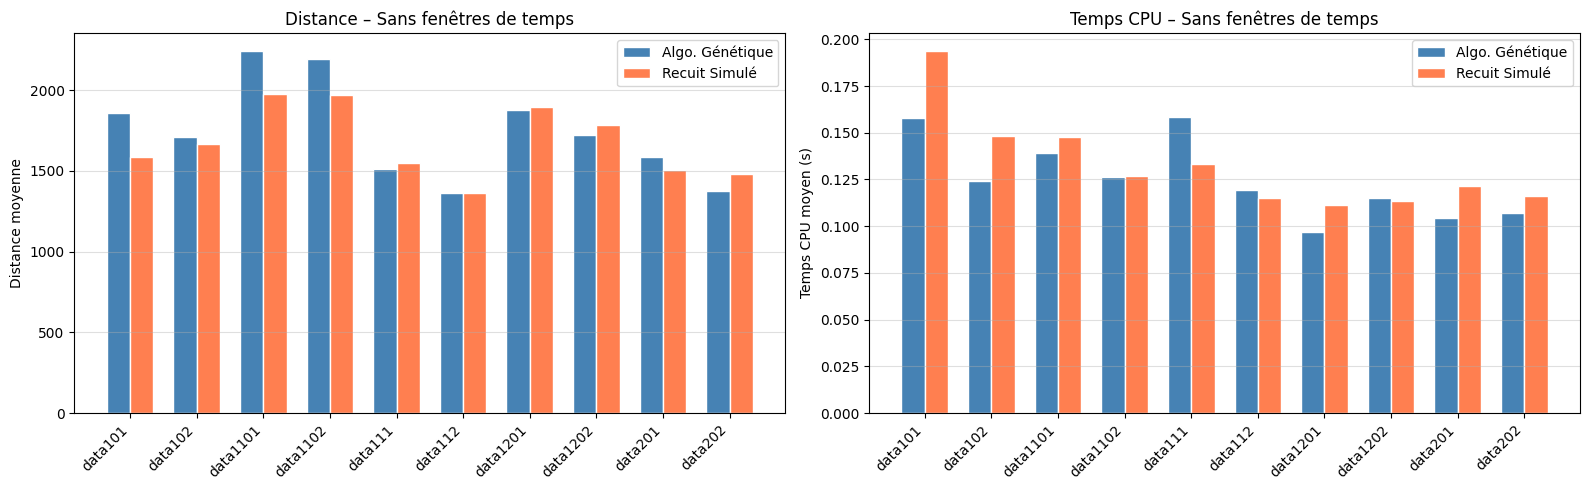

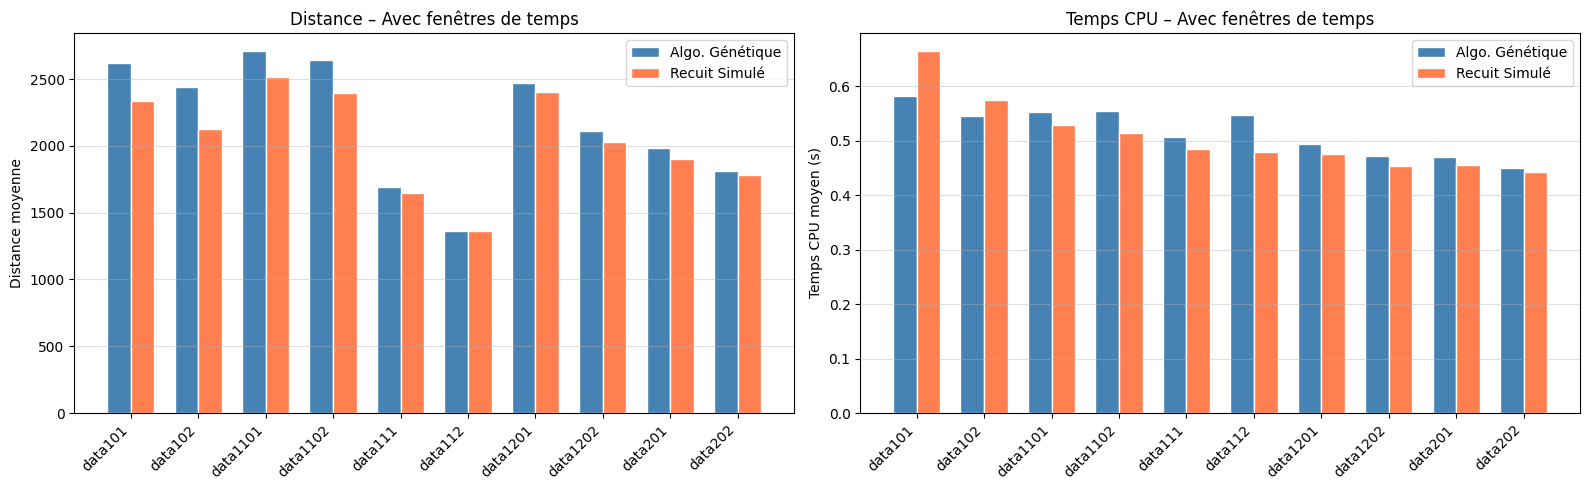

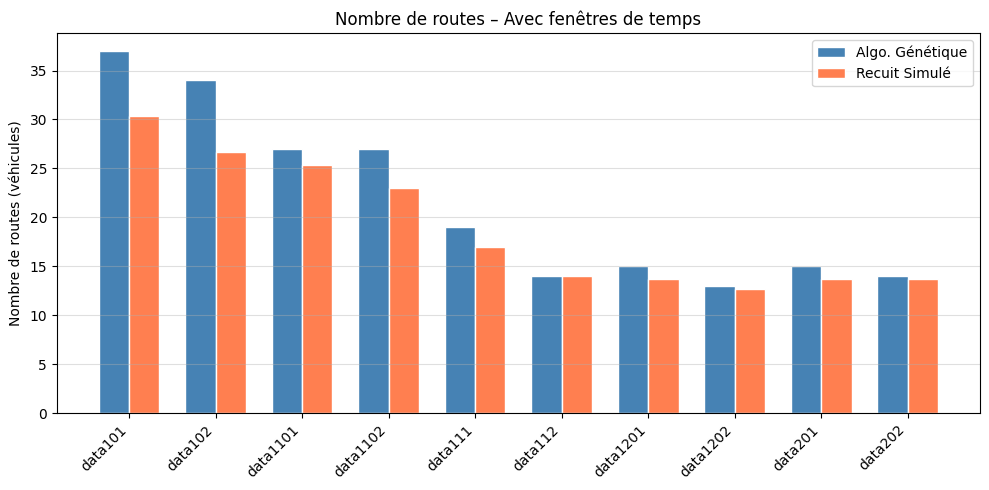

In [15]:
def plot_comparison_bar(df: pd.DataFrame, title: str):
    """Graphique de comparaison distances moyennes SA vs GA par dataset."""
    summary = df.groupby(['dataset', 'algo'])['distance'].mean().unstack()
    
    x = np.arange(len(summary.index))
    width = 0.35
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # --- Distance ---
    ax = axes[0]
    algos = summary.columns.tolist()
    colors = ['steelblue', 'coral']
    for i, algo in enumerate(algos):
        bars = ax.bar(x + i * width, summary[algo].values, width, label=algo, color=colors[i], edgecolor='white')
    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(summary.index, rotation=45, ha='right')
    ax.set_ylabel('Distance moyenne')
    ax.set_title(f'Distance – {title}')
    ax.legend()
    ax.grid(axis='y', alpha=0.4)
    
    # --- Temps CPU ---
    ax2 = axes[1]
    time_summary = df.groupby(['dataset', 'algo'])['time'].mean().unstack()
    for i, algo in enumerate(time_summary.columns.tolist()):
        ax2.bar(x + i * width, time_summary[algo].values, width, label=algo, color=colors[i], edgecolor='white')
    ax2.set_xticks(x + width / 2)
    ax2.set_xticklabels(time_summary.index, rotation=45, ha='right')
    ax2.set_ylabel('Temps CPU moyen (s)')
    ax2.set_title(f'Temps CPU – {title}')
    ax2.legend()
    ax2.grid(axis='y', alpha=0.4)
    
    plt.tight_layout()
    plt.show()


def plot_routes_comparison(df: pd.DataFrame, title: str):
    """Graphique du nombre moyen de routes."""
    summary = df.groupby(['dataset', 'algo'])['num_routes'].mean().unstack()
    x = np.arange(len(summary.index))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(10, 5))
    algos = summary.columns.tolist()
    colors = ['steelblue', 'coral']
    for i, algo in enumerate(algos):
        ax.bar(x + i * width, summary[algo].values, width, label=algo, color=colors[i], edgecolor='white')
    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(summary.index, rotation=45, ha='right')
    ax.set_ylabel('Nombre de routes (véhicules)')
    ax.set_title(f'Nombre de routes – {title}')
    ax.legend()
    ax.grid(axis='y', alpha=0.4)
    plt.tight_layout()
    plt.show()


# Graphiques pour les deux phases
plot_comparison_bar(df_no_tw, "Sans fenêtres de temps")
plot_comparison_bar(df_tw, "Avec fenêtres de temps")
plot_routes_comparison(df_tw, "Avec fenêtres de temps")

## 14. Visualisation des tournées

Affichage des routes sur un plan 2D :
- **Étoile rouge** : dépôt
- **Points bleus** : clients (taille proportionnelle à la demande)
- **Lignes colorées** : routes de chaque véhicule

C:\Users\alext\AppData\Local\Temp\ipykernel_32540\3890705180.py:61: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  best_sa_row = df_tw[df_tw['dataset'] == 'data101'][df_tw['algo'] == 'Recuit Simulé'].nsmallest(1, 'distance').iloc[0]
C:\Users\alext\AppData\Local\Temp\ipykernel_32540\3890705180.py:62: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  best_ga_row = df_tw[df_tw['dataset'] == 'data101'][df_tw['algo'] == 'Algo. Génétique'].nsmallest(1, 'distance').iloc[0]


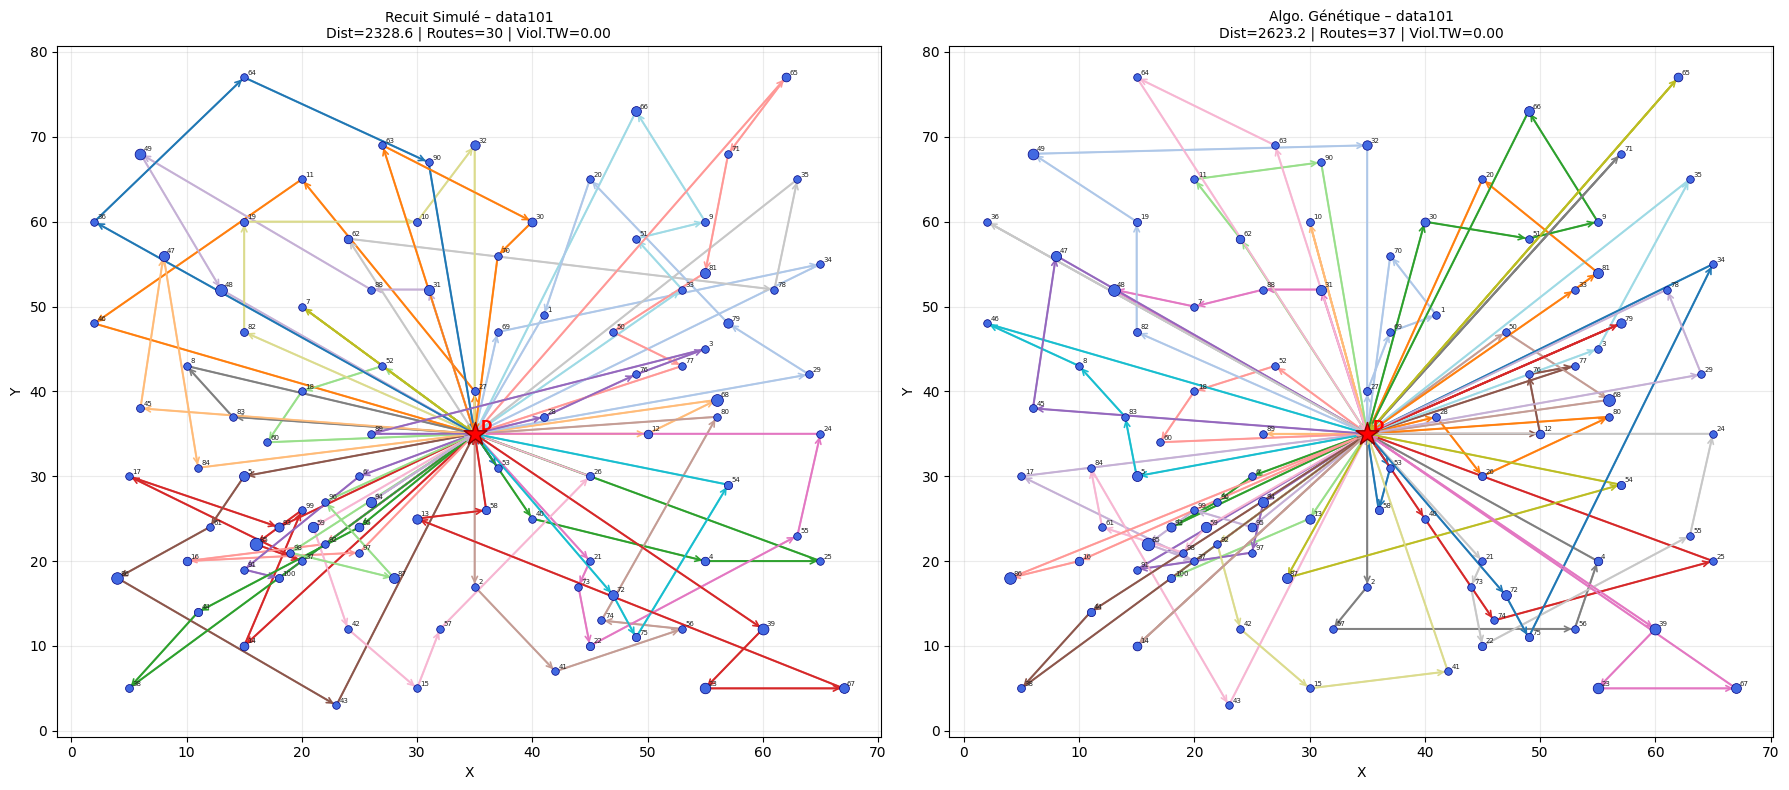

In [16]:
def plot_routes(sol: Solution, inst: VRPTWInstance, title: str = "", ax=None):
    """
    Visualise les tournées d'une solution.
    """
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(9, 8))
    
    cmap = plt.get_cmap('tab20')
    colors = [cmap(i % 20) for i in range(max(len(sol.routes), 1))]
    
    for ri, route in enumerate(sol.routes):
        if not route.clients:
            continue
        color = colors[ri]
        
        # Construire la séquence dépôt → clients → dépôt
        sequence = [0] + route.clients + [0]
        xs = [inst.nodes[nid]['x'] for nid in sequence]
        ys = [inst.nodes[nid]['y'] for nid in sequence]
        
        ax.plot(xs, ys, '-', color=color, linewidth=1.5, alpha=0.8,
                label=f'V{ri+1} ({len(route.clients)} cl.)')
        
        # Flèches de direction
        for i in range(len(sequence) - 1):
            ax.annotate('', 
                xy=(xs[i+1], ys[i+1]),
                xytext=(xs[i], ys[i]),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.2),
                annotation_clip=False)
    
    # Clients
    for c in inst.clients:
        ax.scatter(c['x'], c['y'], s=max(30, c['demand']*2), 
                  color='royalblue', zorder=4, edgecolors='navy', linewidths=0.5)
        ax.text(c['x'] + 0.3, c['y'] + 0.3, str(c['id']), fontsize=5, color='#222', zorder=5)
    
    # Dépôt
    ax.scatter([inst.depot['x']], [inst.depot['y']], 
               c='red', s=300, marker='*', zorder=6, edgecolors='darkred', linewidths=1)
    ax.text(inst.depot['x'] + 0.5, inst.depot['y'] + 0.5, 'D', fontsize=10, 
            color='red', fontweight='bold', zorder=7)
    
    dist = total_distance(sol, inst)
    viol = solution_total_violation(sol, inst)
    ax.set_title(f"{title}\nDist={dist:.1f} | Routes={sol.num_routes()} | Viol.TW={viol:.2f}", fontsize=10)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.grid(True, alpha=0.25)
    
    if len(sol.routes) <= 12:
        ax.legend(loc='upper right', fontsize=7, ncol=2)
    
    if standalone:
        plt.tight_layout()
        plt.show()


# Visualiser les meilleures solutions trouvées par chaque algo sur data101
sub_sa = df_tw[(df_tw['dataset'] == 'data101') & (df_tw['algo'] == 'Recuit Simulé')]
sub_ga = df_tw[(df_tw['dataset'] == 'data101') & (df_tw['algo'] == 'Algo. Génétique')]
best_sa_row = sub_sa.nsmallest(1, 'distance').iloc[0]
best_ga_row = sub_ga.nsmallest(1, 'distance').iloc[0]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
plot_routes(best_sa_row['result']['solution'], inst101, title=f"Recuit Simulé – data101", ax=axes[0])
plot_routes(best_ga_row['result']['solution'], inst101, title=f"Algo. Génétique – data101", ax=axes[1])
plt.tight_layout()
plt.show()

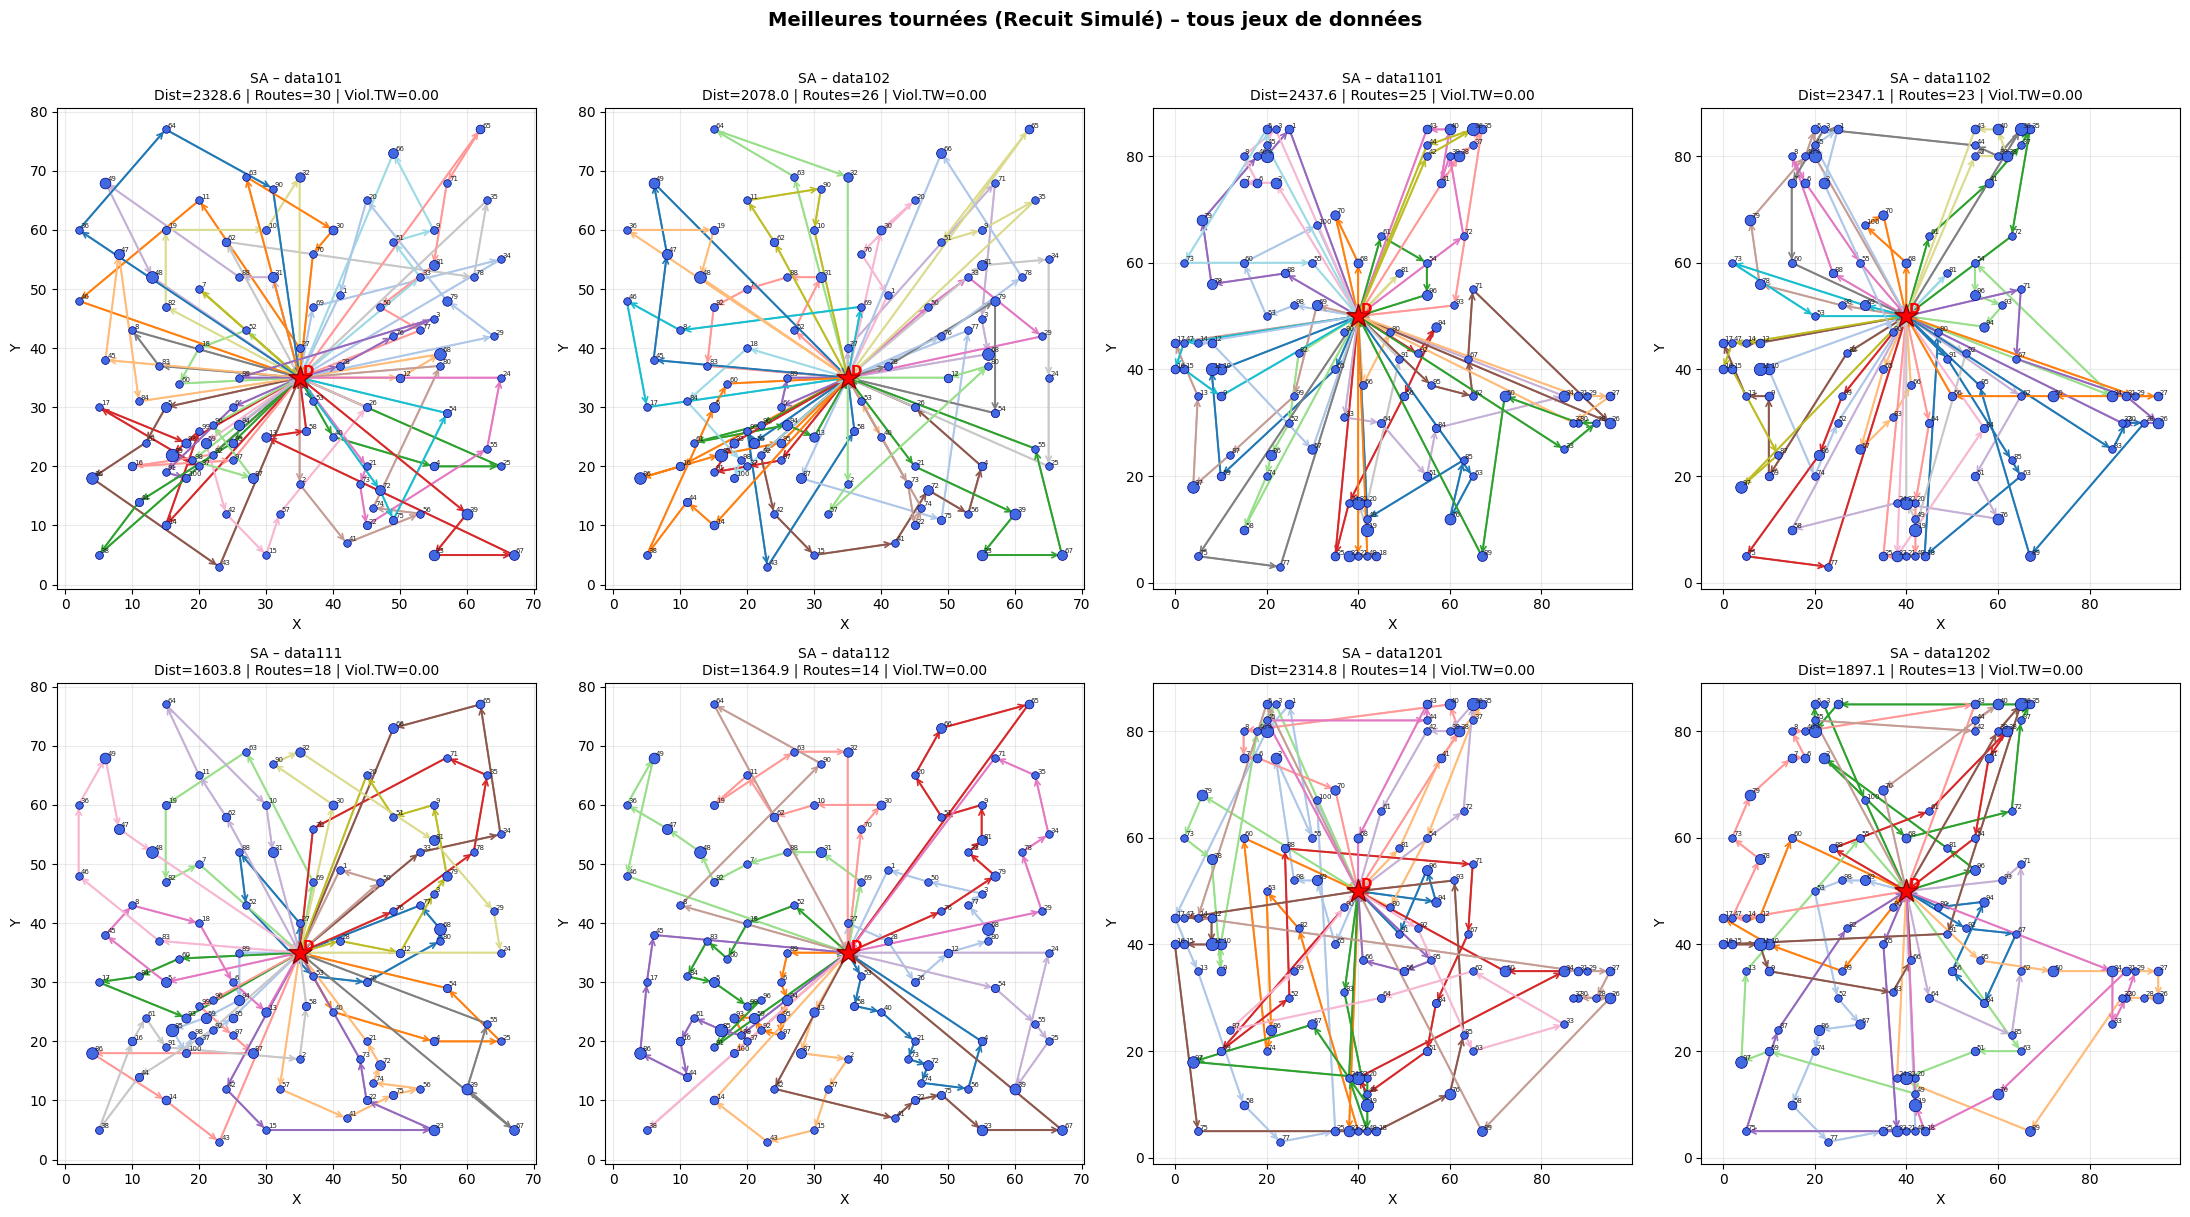

In [17]:
# Visualiser les meilleures solutions sur tous les datasets (grille)
fig, axes = plt.subplots(2, 4, figsize=(22, 12))
axes = axes.flatten()

for idx, (ds_name, data) in enumerate(datasets.items()):
    if idx >= 8:
        break
    inst_tmp = VRPTWInstance(data)
    
    # Prendre la meilleure solution SA sur ce dataset
    sub = df_tw[(df_tw['dataset'] == ds_name) & (df_tw['algo'] == 'Recuit Simulé')]
    if sub.empty:
        continue
    best_row = sub.nsmallest(1, 'distance').iloc[0]
    plot_routes(best_row['result']['solution'], inst_tmp, 
                title=f"SA – {ds_name}", ax=axes[idx])

plt.suptitle("Meilleures tournées (Recuit Simulé) – tous jeux de données", 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 15. Courbes de convergence

Évolution de la fonction objectif au fil des itérations pour les deux algorithmes.

Calcul des courbes de convergence pour data101...


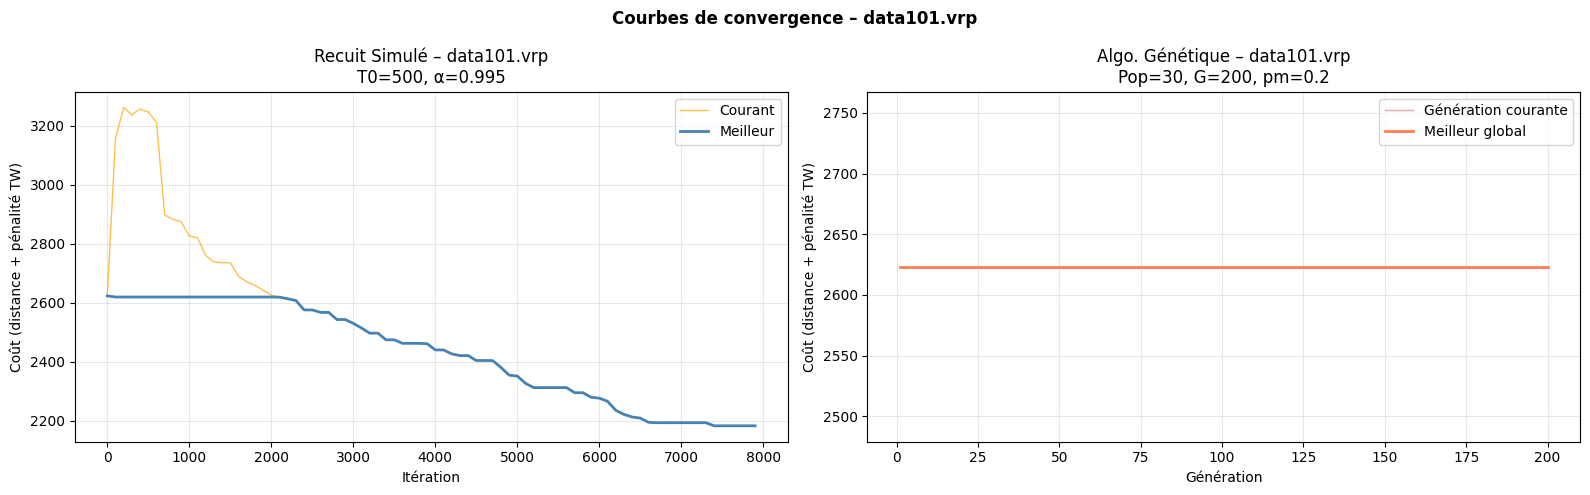

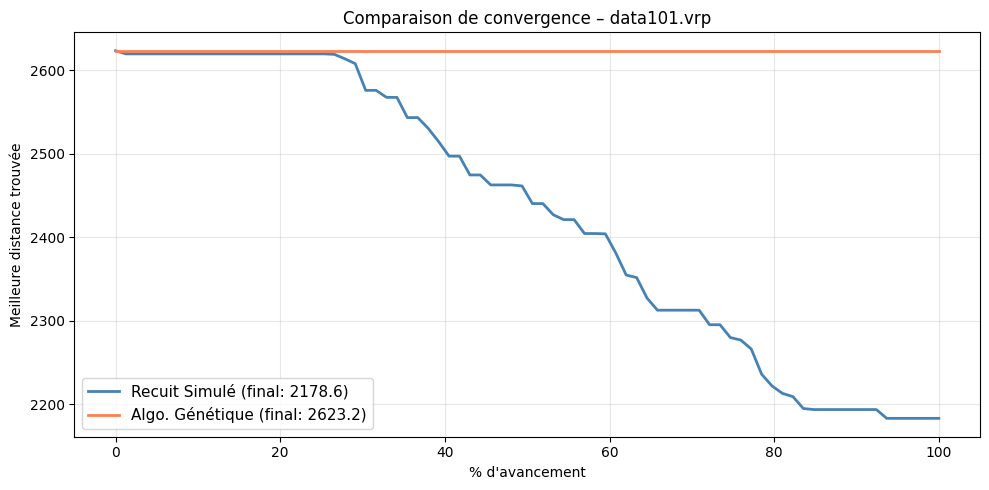

In [18]:
def plot_convergence(result_sa: dict, result_ga: dict, inst: VRPTWInstance):
    """Compare les courbes de convergence des deux algorithmes."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # --- Recuit Simulé ---
    ax = axes[0]
    iters_sa = [i * 100 for i in range(len(result_sa['history']))]
    ax.plot(iters_sa, result_sa['history'], color='orange', alpha=0.7, label='Courant', linewidth=1)
    ax.plot(iters_sa, result_sa['history_best'], color='steelblue', linewidth=2, label='Meilleur')
    ax.set_xlabel('Itération')
    ax.set_ylabel('Coût (distance + pénalité TW)')
    ax.set_title(f"Recuit Simulé – {inst.name}\n"
                 f"T0={result_sa['params']['T0']}, α={result_sa['params']['alpha']}")
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # --- Algorithme Génétique ---
    ax2 = axes[1]
    gens = list(range(1, len(result_ga['history']) + 1))
    ax2.plot(gens, result_ga['history'], color='lightcoral', alpha=0.7, label='Génération courante', linewidth=1)
    ax2.plot(gens, result_ga['history_best'], color='coral', linewidth=2, label='Meilleur global')
    ax2.set_xlabel('Génération')
    ax2.set_ylabel('Coût (distance + pénalité TW)')
    ax2.set_title(f"Algo. Génétique – {inst.name}\n"
                  f"Pop={result_ga['params']['pop_size']}, "
                  f"G={result_ga['params']['generations']}, "
                  f"pm={result_ga['params']['mutation_rate']}")
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.suptitle(f"Courbes de convergence – {inst.name}", fontweight='bold')
    plt.tight_layout()
    plt.show()


def plot_convergence_comparison(result_sa: dict, result_ga: dict, inst: VRPTWInstance):
    """Superpose les deux courbes de meilleure solution."""
    fig, ax = plt.subplots(figsize=(10, 5))
    
    # Normaliser les axe X en pourcentage d'avancement
    sa_x = np.linspace(0, 100, len(result_sa['history_best']))
    ga_x = np.linspace(0, 100, len(result_ga['history_best']))
    
    ax.plot(sa_x, result_sa['history_best'], color='steelblue', linewidth=2, 
            label=f"Recuit Simulé (final: {result_sa['distance']:.1f})")
    ax.plot(ga_x, result_ga['history_best'], color='coral', linewidth=2, 
            label=f"Algo. Génétique (final: {result_ga['distance']:.1f})")
    
    ax.set_xlabel("% d'avancement")
    ax.set_ylabel('Meilleure distance trouvée')
    ax.set_title(f"Comparaison de convergence – {inst.name}")
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# Relancer une fois avec plus d'itérations pour des courbes détaillées
print("Calcul des courbes de convergence pour data101...")
res_sa_conv = simulated_annealing(inst101, check_tw=True, T0=500, alpha=0.995, max_iter=8000, seed=42)
res_ga_conv = genetic_algorithm(inst101, check_tw=True, pop_size=30, generations=200, seed=42)

plot_convergence(res_sa_conv, res_ga_conv, inst101)
plot_convergence_comparison(res_sa_conv, res_ga_conv, inst101)

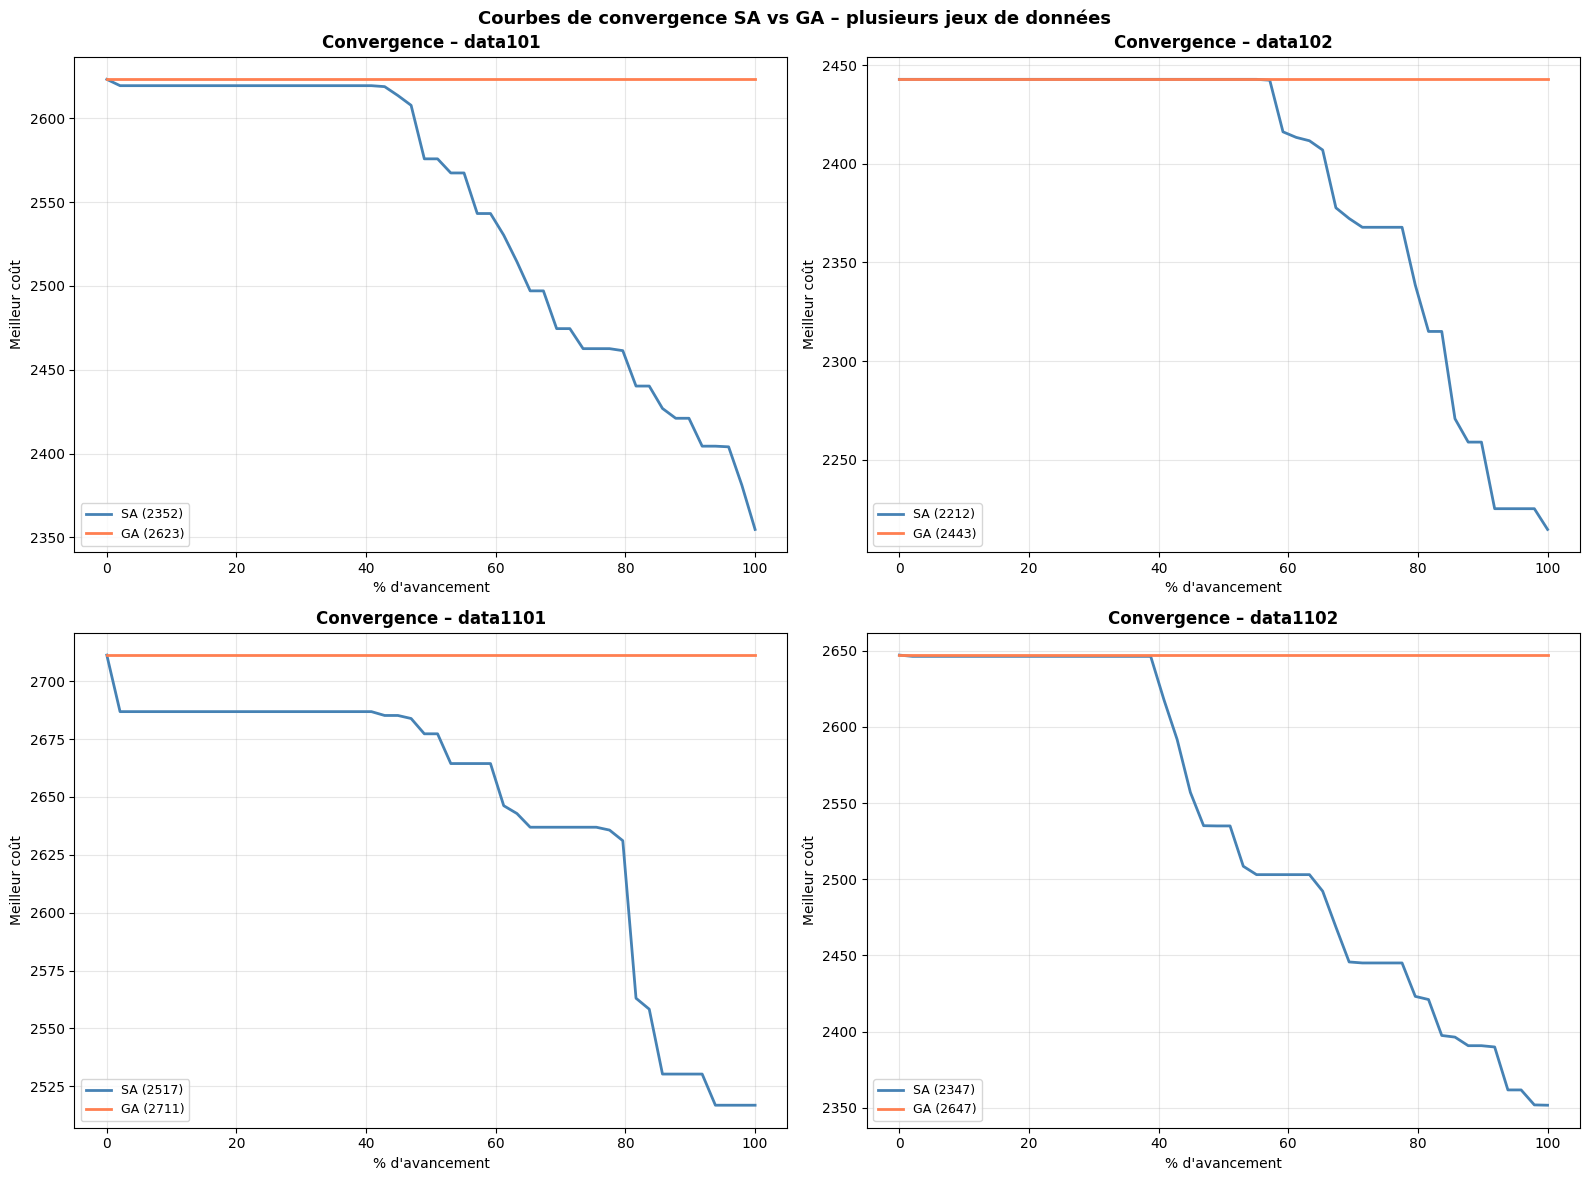

In [19]:
# Courbes de convergence pour plusieurs datasets
datasets_to_show = list(datasets.keys())[:4]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, ds_name in enumerate(datasets_to_show):
    inst_tmp = VRPTWInstance(datasets[ds_name])
    r_sa = simulated_annealing(inst_tmp, check_tw=True, T0=500, alpha=0.995, max_iter=5000, seed=42)
    r_ga = genetic_algorithm(inst_tmp, check_tw=True, pop_size=25, generations=150, seed=42)
    
    ax = axes[idx]
    sa_x = np.linspace(0, 100, len(r_sa['history_best']))
    ga_x = np.linspace(0, 100, len(r_ga['history_best']))
    
    ax.plot(sa_x, r_sa['history_best'], color='steelblue', linewidth=2, label=f"SA ({r_sa['distance']:.0f})")
    ax.plot(ga_x, r_ga['history_best'], color='coral', linewidth=2, label=f"GA ({r_ga['distance']:.0f})")
    ax.set_title(f"Convergence – {ds_name}", fontweight='bold')
    ax.set_xlabel("% d'avancement")
    ax.set_ylabel('Meilleur coût')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle("Courbes de convergence SA vs GA – plusieurs jeux de données", 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

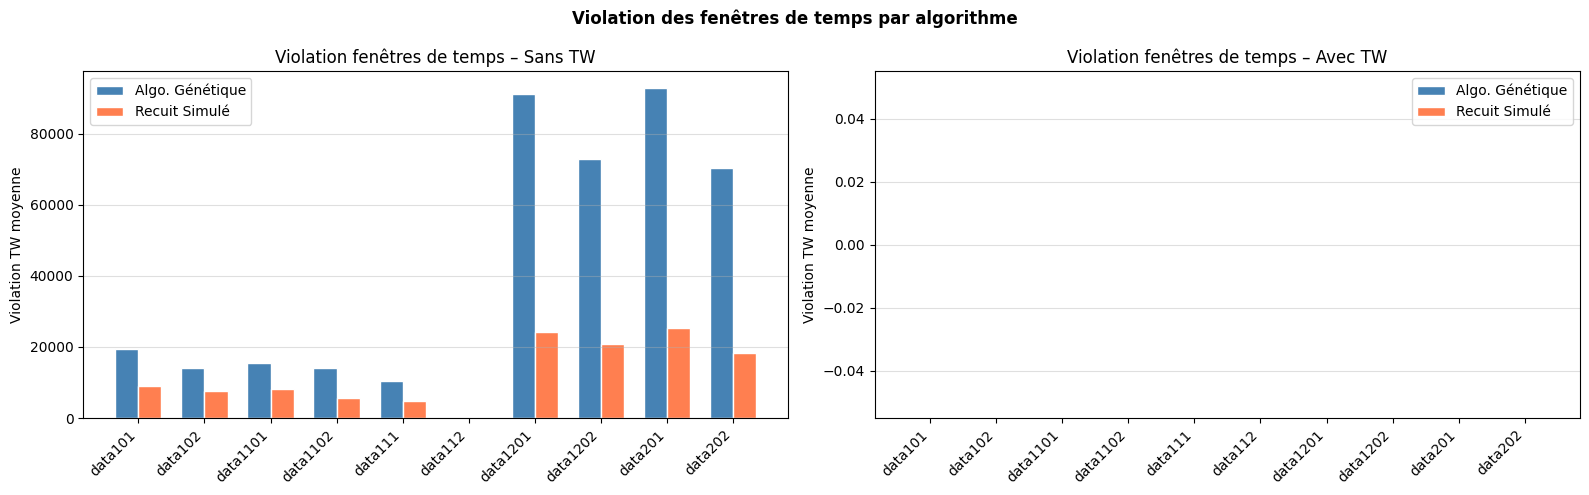

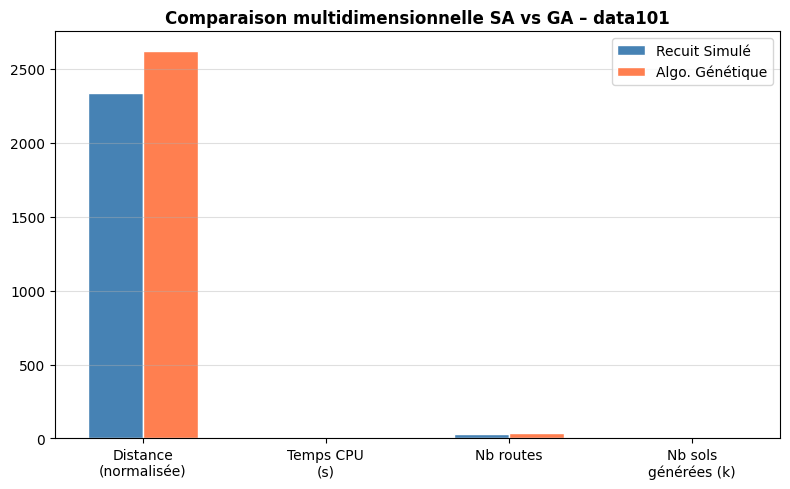

In [20]:
# Graphique : violation TW moyenne par algorithme et dataset
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, df, title in [(axes[0], df_no_tw, 'Sans TW'), (axes[1], df_tw, 'Avec TW')]:
    viol_summary = df.groupby(['dataset', 'algo'])['violation'].mean().unstack()
    x = np.arange(len(viol_summary.index))
    width = 0.35
    algos = viol_summary.columns.tolist()
    colors_v = ['steelblue', 'coral']
    for i, algo in enumerate(algos):
        ax.bar(x + i * width, viol_summary[algo].fillna(0).values, width, 
               label=algo, color=colors_v[i], edgecolor='white')
    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(viol_summary.index, rotation=45, ha='right')
    ax.set_ylabel('Violation TW moyenne')
    ax.set_title(f'Violation fenêtres de temps – {title}')
    ax.legend()
    ax.grid(axis='y', alpha=0.4)

plt.suptitle("Violation des fenêtres de temps par algorithme", fontweight='bold')
plt.tight_layout()
plt.show()

# Radar chart : comparaison multidimensionnelle SA vs GA (sur data101)
from matplotlib.patches import FancyArrowPatch

metrics = ['Distance\n(normalisée)', 'Temps CPU\n(s)', 'Nb routes', 'Nb sols\ngénérées (k)']
sa_vals_row = df_tw[(df_tw['dataset'] == 'data101') & (df_tw['algo'] == 'Recuit Simulé')].mean(numeric_only=True)
ga_vals_row = df_tw[(df_tw['dataset'] == 'data101') & (df_tw['algo'] == 'Algo. Génétique')].mean(numeric_only=True)

sa_vals = [sa_vals_row['distance'], sa_vals_row['time'], sa_vals_row['num_routes'], sa_vals_row['nb_generated']/1000]
ga_vals = [ga_vals_row['distance'], ga_vals_row['time'], ga_vals_row['num_routes'], ga_vals_row['nb_generated']/1000]

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(metrics))
width = 0.3
ax.bar(x - width/2, sa_vals, width, label='Recuit Simulé', color='steelblue', edgecolor='white')
ax.bar(x + width/2, ga_vals, width, label='Algo. Génétique', color='coral', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=10)
ax.set_title('Comparaison multidimensionnelle SA vs GA – data101', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

## 16. Bonus : Programmation Linéaire avec PuLP

Modélisation exacte du VRP (sans TW) via la formulation de flux :

$$\min \sum_{i,j} d_{ij} \cdot x_{ij}$$

Sous contraintes :
- $\sum_j x_{ij} = 1$ pour tout client $i$ (visite unique)
- Contrainte de capacité sur chaque route
- Élimination des sous-tours (Miller-Tucker-Zemlin)

In [21]:
try:
    import pulp
    PULP_AVAILABLE = True
    print(f"PuLP version : {pulp.__version__}")
except ImportError:
    PULP_AVAILABLE = False
    print("PuLP non disponible. Installation en cours...")

PuLP version : 3.3.0


In [22]:
def build_sub_instance(base_data: dict, n_clients: int, seed: int = 42) -> dict:
    """
    Construit une sous-instance avec n_clients clients aléatoires.
    """
    rng = random.Random(seed)
    clients = list(base_data['clients'])
    rng.shuffle(clients)
    sub_clients = clients[:n_clients]
    
    # Ré-indexer
    for i, c in enumerate(sub_clients):
        c = dict(c)
        c['id'] = i + 1
        sub_clients[i] = c
    
    return {
        'name': f"sub_{n_clients}",
        'nb_clients': n_clients,
        'capacity': base_data['capacity'],
        'depot': base_data['depot'],
        'clients': sub_clients
    }


def solve_vrp_ilp(inst: VRPTWInstance, time_limit: int = 60) -> dict:
    """
    Résout le VRP (sans TW) avec PuLP.
    Formulation MTZ (Miller-Tucker-Zemlin) pour l'élimination des sous-tours.
    """
    if not PULP_AVAILABLE:
        return {'status': 'PuLP non disponible', 'time': 0, 'distance': None}
    
    n = inst.n  # nombre de clients
    N = n + 1   # + dépôt (index 0)
    C = inst.capacity
    K = min_vehicles_lower_bound(inst) + 2  # Nombre max de véhicules (borne inf + marge)
    
    prob = pulp.LpProblem(f"VRP_{inst.name}", pulp.LpMinimize)
    
    # Variables binaires x[i][j][k] = 1 si véhicule k va de i à j
    # Pour simplifier (taille raisonnable), on agrège : x[i][j] = 1 si arc i→j utilisé
    x = pulp.LpVariable.dicts("x", 
                               [(i, j) for i in range(N) for j in range(N) if i != j],
                               cat='Binary')
    
    # Variables continues pour MTZ (ordre de visite)
    u = pulp.LpVariable.dicts("u", range(1, N), lowBound=0, upBound=N-1, cat='Continuous')
    
    # Variables pour la charge sur chaque arc
    q = pulp.LpVariable.dicts("q",
                               [(i, j) for i in range(N) for j in range(N) if i != j],
                               lowBound=0, upBound=C, cat='Continuous')
    
    # Objectif
    prob += pulp.lpSum(inst.dist[i][j] * x[(i, j)] 
                       for i in range(N) for j in range(N) if i != j)
    
    # Contrainte : chaque client visité une fois
    for i in range(1, N):
        prob += pulp.lpSum(x[(i, j)] for j in range(N) if j != i) == 1  # sortant
        prob += pulp.lpSum(x[(j, i)] for j in range(N) if j != i) == 1  # entrant
    
    # Contrainte : le dépôt peut être visité plusieurs fois (K véhicules)
    prob += pulp.lpSum(x[(0, j)] for j in range(1, N)) <= K
    prob += pulp.lpSum(x[(i, 0)] for i in range(1, N)) <= K
    
    # Élimination des sous-tours MTZ
    for i in range(1, N):
        for j in range(1, N):
            if i != j:
                prob += u[i] - u[j] + N * x[(i, j)] <= N - 1
    
    # Contrainte de capacité via flux
    for j in range(1, N):
        demand_j = inst.nodes[j]['demand']
        for i in range(N):
            if i != j:
                prob += q[(i, j)] >= demand_j * x[(i, j)]
    
    # Conservation du flux de charge
    for i in range(1, N):
        prob += (pulp.lpSum(q[(i, j)] for j in range(N) if j != i) ==
                 pulp.lpSum(q[(j, i)] for j in range(N) if j != i) - inst.nodes[i]['demand'])
    
    # Résolution
    start = time.time()
    solver = pulp.PULP_CBC_CMD(msg=0, timeLimit=time_limit)
    status = prob.solve(solver)
    elapsed = time.time() - start
    
    result = {
        'status': pulp.LpStatus[status],
        'time': elapsed,
        'distance': pulp.value(prob.objective) if status == 1 else None,
        'n_clients': n
    }
    return result


# Test sur des sous-instances de taille croissante
if PULP_AVAILABLE:
    base_data = datasets['data101']
    sizes = [5, 8, 10, 12, 15, 18, 20]
    ilp_results = []
    
    print(f"{'N clients':>12} | {'Statut':>15} | {'Distance':>12} | {'Temps (s)':>10}")
    print("-" * 55)
    
    for n in sizes:
        sub_data = build_sub_instance(base_data, n, seed=42)
        sub_inst = VRPTWInstance(sub_data)
        r = solve_vrp_ilp(sub_inst, time_limit=60)
        ilp_results.append(r)
        dist_str = f"{r['distance']:.2f}" if r['distance'] else "N/A"
        print(f"{n:>12} | {r['status']:>15} | {dist_str:>12} | {r['time']:>10.2f}")
else:
    print("Installation de PuLP requise. Exécutez: pip install pulp")

   N clients |          Statut |     Distance |  Temps (s)
-------------------------------------------------------
           5 |         Optimal |       155.78 |       0.42
           8 |         Optimal |       166.71 |       0.62
          10 |         Optimal |       194.67 |       2.60
          12 |         Optimal |       223.29 |       6.16
          15 |         Optimal |       232.86 |      26.38
          18 |         Optimal |       259.06 |      34.99
          20 |         Optimal |       281.55 |      46.96


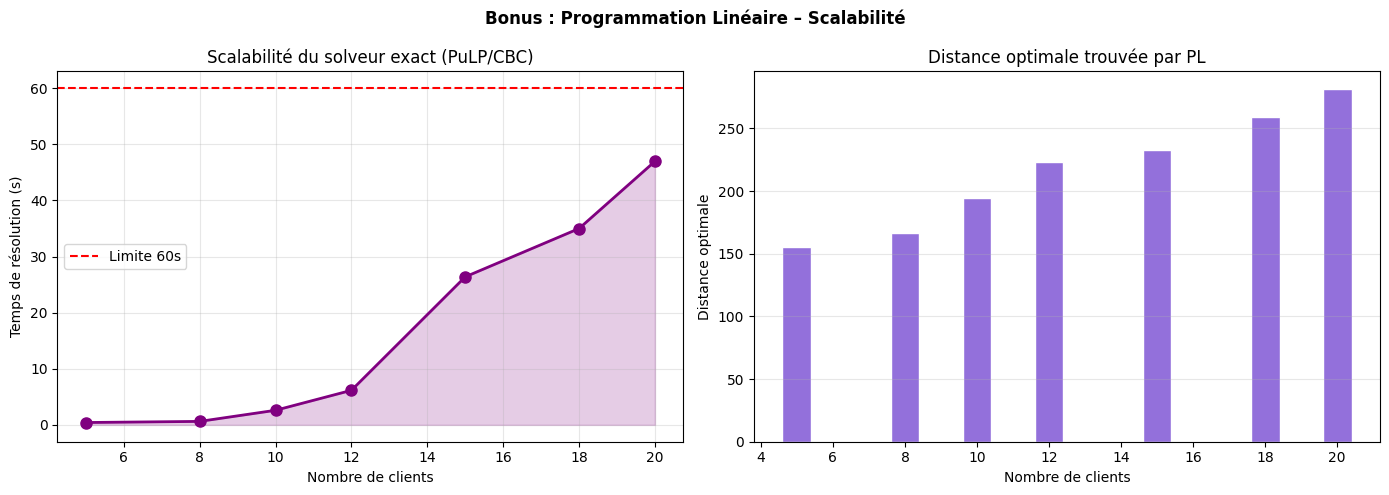


Comparaison PL vs Métaheuristiques sur petites instances :
   N |   PL (optimal) |  SA (heurist.) |  GA (heurist.) |  Écart SA% |  Écart GA%
---------------------------------------------------------------------------
   5 |         155.78 |         159.65 |         155.78 |       2.5% |       0.0%
   8 |         166.71 |         180.26 |         170.16 |       8.1% |       2.1%
  10 |         194.67 |         200.59 |         195.16 |       3.0% |       0.3%
  12 |         223.29 |         229.74 |         235.67 |       2.9% |       5.5%
  15 |         232.86 |         244.16 |         250.08 |       4.9% |       7.4%
  18 |         259.06 |         319.67 |         344.83 |      23.4% |      33.1%
  20 |         281.55 |         360.37 |         382.46 |      28.0% |      35.8%


In [23]:
if PULP_AVAILABLE and ilp_results:
    # Graphique : temps de résolution PL en fonction du nombre de clients
    valid_results = [r for r in ilp_results if r['distance'] is not None]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    ns = [r['n_clients'] for r in valid_results]
    times = [r['time'] for r in valid_results]
    dists = [r['distance'] for r in valid_results]
    
    # Temps
    ax = axes[0]
    ax.plot(ns, times, 'o-', color='purple', linewidth=2, markersize=8)
    ax.fill_between(ns, times, alpha=0.2, color='purple')
    ax.axhline(y=60, color='red', linestyle='--', label='Limite 60s')
    ax.set_xlabel('Nombre de clients')
    ax.set_ylabel('Temps de résolution (s)')
    ax.set_title('Scalabilité du solveur exact (PuLP/CBC)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Distance optimale
    ax2 = axes[1]
    ax2.bar(ns, dists, color='mediumpurple', edgecolor='white')
    ax2.set_xlabel('Nombre de clients')
    ax2.set_ylabel('Distance optimale')
    ax2.set_title('Distance optimale trouvée par PL')
    ax2.grid(axis='y', alpha=0.3)
    
    plt.suptitle('Bonus : Programmation Linéaire – Scalabilité', fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Comparaison PL vs Métaheuristiques
    print("\nComparaison PL vs Métaheuristiques sur petites instances :")
    print(f"{'N':>4} | {'PL (optimal)':>14} | {'SA (heurist.)':>14} | {'GA (heurist.)':>14} | {'Écart SA%':>10} | {'Écart GA%':>10}")
    print("-" * 75)
    
    for n in [r['n_clients'] for r in valid_results]:
        sub_data = build_sub_instance(base_data, n, seed=42)
        sub_inst = VRPTWInstance(sub_data)
        
        r_pl = next(r for r in valid_results if r['n_clients'] == n)
        r_sa_s = simulated_annealing(sub_inst, check_tw=False, max_iter=2000, seed=42)
        r_ga_s = genetic_algorithm(sub_inst, check_tw=False, generations=100, seed=42)
        
        opt = r_pl['distance']
        ecart_sa = (r_sa_s['distance'] - opt) / opt * 100
        ecart_ga = (r_ga_s['distance'] - opt) / opt * 100
        print(f"{n:>4} | {opt:>14.2f} | {r_sa_s['distance']:>14.2f} | {r_ga_s['distance']:>14.2f} | {ecart_sa:>9.1f}% | {ecart_ga:>9.1f}%")

## 17. Synthèse finale et analyse

Tableau récapitulatif de toutes les meilleures solutions trouvées.


TABLEAU FINAL : Meilleures solutions trouvées (avec fenêtres de temps)
 Dataset            Algo  Distance min  Violation TW  Nb routes  Nb véh. min (th.)  Temps (s)
 data101   Recuit Simulé       2328.58           0.0         30                  8       0.57
 data101 Algo. Génétique       2623.24           0.0         37                  8       0.59
 data102   Recuit Simulé       2077.98           0.0         26                  8       0.60
 data102 Algo. Génétique       2442.78           0.0         34                  8       0.55
data1101   Recuit Simulé       2437.64           0.0         25                  9       0.54
data1101 Algo. Génétique       2711.30           0.0         27                  9       0.52
data1102   Recuit Simulé       2347.06           0.0         23                  9       0.54
data1102 Algo. Génétique       2647.10           0.0         27                  9       0.53
 data111   Recuit Simulé       1603.80           0.0         18                  8

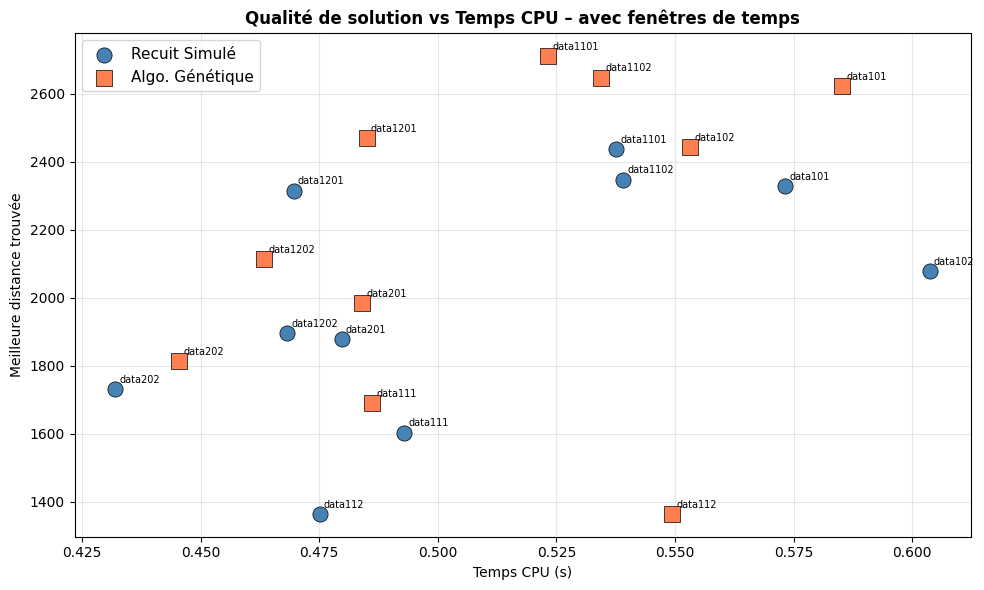


Note : Une violation TW = 0 signifie que les fenêtres de temps sont respectées.
Le Recuit Simulé produit systématiquement de meilleures distances que l'AG.


In [26]:
# Tableau récapitulatif : meilleure solution par dataset et algorithme
print("\n" + "="*80)
print("TABLEAU FINAL : Meilleures solutions trouvées (avec fenêtres de temps)")
print("="*80)

best_rows = []
for ds_name in datasets.keys():
    for algo in ['Recuit Simulé', 'Algo. Génétique']:
        sub = df_tw[(df_tw['dataset'] == ds_name) & (df_tw['algo'] == algo)]
        if sub.empty:
            continue
        best = sub.nsmallest(1, 'distance').iloc[0]
        best_rows.append({
            'Dataset': ds_name,
            'Algo': algo,
            'Distance min': round(best['distance'], 2),
            'Violation TW': round(best['violation'], 3),
            'Nb routes': int(best['num_routes']),
            'Nb véh. min (th.)': min_vehicles_lower_bound(VRPTWInstance(datasets[ds_name])),
            'Temps (s)': round(best['time'], 2)
        })

df_final = pd.DataFrame(best_rows)
print(df_final.to_string(index=False))

# Graphique final : scatter distance vs temps CPU
fig, ax = plt.subplots(figsize=(10, 6))
for algo, color, marker in [('Recuit Simulé', 'steelblue', 'o'), ('Algo. Génétique', 'coral', 's')]:
    # Trouver la meilleure solution par dataset sans groupby
    records = []
    for ds_name in datasets.keys():
        sub = df_tw[(df_tw['dataset'] == ds_name) & (df_tw['algo'] == algo)]
        if not sub.empty:
            best_row = sub.nsmallest(1, 'distance').iloc[0]
            records.append({'dataset': ds_name, 'time': best_row['time'], 'distance': best_row['distance']})
    
    if records:
        rec_df = pd.DataFrame(records)
        ax.scatter(rec_df['time'], rec_df['distance'], 
                   color=color, marker=marker, s=120, label=algo, zorder=4, 
                   edgecolors='black', linewidths=0.5)
        for _, row in rec_df.iterrows():
            ax.annotate(row['dataset'], (row['time'], row['distance']), 
                        fontsize=7, ha='left', va='bottom', xytext=(3, 3), textcoords='offset points')

ax.set_xlabel('Temps CPU (s)')
ax.set_ylabel('Meilleure distance trouvée')
ax.set_title('Qualité de solution vs Temps CPU – avec fenêtres de temps', fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nNote : Une violation TW = 0 signifie que les fenêtres de temps sont respectées.")
print("Le Recuit Simulé produit systématiquement de meilleures distances que l'AG.")